# MMMU-Pro Eval300 × InternVL3.5-8B Q4_K_M — P1 CoT

**Production, paper-oriented, resume-safe P1 evaluation notebook**

This is the **P1 / Chain-of-Thought (CoT)** condition. The single-stage pipeline
is unchanged; the prompt adds exactly:

`Think step by step before answering.`

Exact P1 suffix:

```text
Answer the preceding multiple choice question.
The last line of your response should be of the following format:
'Answer: $LETTER' (without quotes) where LETTER is one of options.
Think step by step before answering.
Explain your reasoning before answering.
```

Local model:
`internvl35_8b_saved/InternVL3_5-8B-Q4_K_M.gguf`
with `internvl35_8b_saved/mmproj-model-f16.gguf`.

`MAX_TOKENS=8192`, `CTX_SIZE=16384`, temperature `0.0`, seed `42`.


## Revision note — reconstruct Eval300 from a frozen ordered ID list

The evaluation subset is reconstructed from the official Hugging Face source:

```text
MMMU/MMMU_Pro / standard (10 options) / test
```

at the exact immutable source revision:

```text
563f3e84bb3b90893083a1f039cfa13077f2302b
```

The notebook first downloads all 1,730 rows in this source setting and then
performs exact ID lookup using `selected_ids.txt`. There is no re-sampling,
nearest-match lookup, question-text matching, or subject-based replacement.

The line order of `selected_ids.txt` is the evaluation order. Candidate options
are preserved row-faithfully:

- answer letters are derived dynamically from each row's actual option count;
- every option is preserved exactly as published;
- no option is padded, truncated, invented, or rewritten;
- every gold label must be valid for the row's actual choice set;
- the selected option-count distribution is archived.

Because the inference notebook receives only the frozen ID list (not the
few-shot pool), it does **not** claim to independently recompute few-shot
disjointness. That property belongs to the upstream dataset-construction stage.
This notebook instead proves that it evaluates the exact cryptographically
pinned ID list produced by that stage.


## Fixed generation / reproducibility protocol

The model, projector, runtime, dataset revision, ordered selection, prompt,
image transport, generation parameters and request seed are cryptographically
or structurally pinned. The request seed records the protocol; it is not a claim
of bitwise determinism across different GPU/runtime builds.

The parser version is intentionally separated from the inference signature:
changing analysis code never makes an incompatible model request resumable.


# 0. Kaggle resume protocol — P1 CoT

Attach:
`internvl35_8b_saved/InternVL3_5-8B-Q4_K_M.gguf`,
`internvl35_8b_saved/mmproj-model-f16.gguf`,
`internvl35_8b_saved/model_manifest.json`, and normally
`internvl35_llama_runtime/llama` (or sibling `llama_runtime/llama`).

Attach frozen Eval300 `selected_ids.txt`, use **2× NVIDIA T4**, and resume only
from this exact P1 experiment. No model/projector/runtime download fallback.


# 1. Install only missing Python packages

This cell installs only lightweight missing Python dependencies. It never
downloads the large model, projector, or llama runtime. Those three artifacts
must come from the saved Kaggle Input bundle shown in the notebook Inputs pane.
The official pinned MMMU-Pro source is downloaded later for exact-ID
reconstruction of Eval300.


In [1]:
import importlib.util, subprocess, sys

requirements = {
    "datasets": "datasets>=3.0",
    "huggingface_hub": "huggingface_hub>=0.24",
    "requests": "requests>=2.31",
    "sklearn": "scikit-learn>=1.3",
    "statsmodels": "statsmodels>=0.14",
    "PIL": "Pillow>=10",
    "pandas": "pandas>=2",
    "numpy": "numpy>=1.26",
    "matplotlib": "matplotlib>=3.8",
}

to_install = [
    spec for mod, spec in requirements.items()
    if importlib.util.find_spec(mod) is None
]

if to_install:
    print("Installing only missing lightweight packages:", to_install)
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *to_install]
    )
else:
    print("All required Python packages already available.")

print("No model/runtime/MMMU-Pro download was performed by this cell.")


All required Python packages already available.
No model/runtime/MMMU-Pro download was performed by this cell.


# 2. Frozen experimental configuration

The block below is the protocol control plane. Do not alter it between runs
that will be merged into one reported experiment.


In [2]:
import os, io, re, ast, json, time, math, base64, random, string, shutil
import hashlib, html, platform, subprocess, sys, shlex, threading, logging, importlib.metadata
from pathlib import Path
from datetime import datetime, timezone
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from PIL import Image
from tqdm.auto import tqdm
from datasets import load_dataset, Image as HFImage
from huggingface_hub import snapshot_download
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, f1_score,
    balanced_accuracy_score, matthews_corrcoef, cohen_kappa_score,
    confusion_matrix,
)
from statsmodels.stats.proportion import proportion_confint

EXPERIMENT_ID = (
    "MMMUPro-Eval300__InternVL3.5-8B-Q4_K_M__"
    "P1-CoT-StepByStep__LocalLlamaCpp__"
    "ImageOrderFix__ValidatedResume__LongDeferredTimeout__"
    "Temperature0__Seed42__MAX8192__CTX16384__LocalInput"
)
PROMPT_ID = "P1-CoT-StepByStep"
PROMPT_FAMILY = "Zero-shot chain-of-thought prompting"
EVALUATION_COHORT_ID = "MMMUPro-frozen-balanced-eval300-v1"

MODEL = "InternVL3.5-8B-Q4_K_M"
MODEL_API_NAME = "internvl3.5-8b"
BASE_MODEL = "OpenGVLab/InternVL3_5-8B"
MODEL_REPO = "lmstudio-community/InternVL3_5-8B-GGUF"
QUANTIZATION = "Q4_K_M"
MODEL_FILENAME = "InternVL3_5-8B-Q4_K_M.gguf"
MMPROJ_FILENAME = "mmproj-model-f16.gguf"
MMPROJ_PRECISION = "F16"
MODEL_SHA256 = "2809043479b8d3aab30378766c7a2a4bd93eedd97c86efc6d65d627fd680faba"
MMPROJ_SHA256 = "212cc090f81ea2981b870186d4b424fae69489a5313a14e52ffdb2e877852389"

# Provenance of the exact saved artifacts. The notebook still loads the local
# Kaggle files; these revisions are metadata identities, not download instructions.
MODEL_ARTIFACT_REVISION = "ae2ec0fbf3e4abb20a33e9d682c5ebf33f638ab7"
MMPROJ_ARTIFACT_REVISION = "98b41ac52d1cfb464694a45faab81ab685ad2dfb"
LLAMA_CPP_COMMIT = "50f068fff"

PROVIDER = "local llama.cpp"
API_METHOD = "OpenAI-compatible /v1/chat/completions"
API_MODE = "local stateless HTTP"
SDK_PIN = "llama.app build 10679 commit 50f068fff; exact local binary SHA-256 pinned"
LLAMA_RUNTIME_SHA256 = "29cf4dddaad7d8249546e1258e553e12435749345db37905a5dd0c5c35e3e36f"
LLAMA_RUNTIME_POLICY = (
    "use only the attached local InternVL llama runtime; require exact "
    "SHA-256 and build-10679 / 50f068fff version identity"
)

INPUT_ROOT = Path("/kaggle/input")
LOCAL_MODEL_DIRNAME = "internvl35_8b_saved"
LOCAL_RUNTIME_DIRNAME = "internvl35_llama_runtime"
LOCAL_MANIFEST_FILENAME = "model_manifest.json"

DATASET_REPO = "MMMU/MMMU_Pro"
DATASET_CONFIG = "standard (10 options)"
DATASET_SUBDIR = "standard (10 options)"
DATASET_SPLIT = "test"
DATASET_REVISION = "563f3e84bb3b90893083a1f039cfa13077f2302b"
REVISION_SOURCE = "hard-pinned full Hugging Face commit SHA"
EXPECTED_SOURCE_N = 1730
EXPECTED_N = 300

EXPECTED_SOURCE_OPTION_COUNT_DISTRIBUTION = {
    2: 28, 3: 42, 4: 125, 5: 41, 6: 16, 7: 12,
    8: 31, 9: 221, 10: 1213, 12: 1,
}

SELECTION_PROTOCOL_NAME = (
    "fixed ordered selected_ids.txt; exact ID extraction from pinned official "
    "MMMU-Pro standard (10 options) test source; no resampling"
)
EXPECTED_SELECTED_IDS_CANONICAL_SHA256 = (
    "db7ec6dca5dff71d8ea8551a08c448c4314e153509ce9c78d2e8c652011a5dc3"
)

INPUT_ROOT = Path("/kaggle/input")
if not INPUT_ROOT.exists():
    raise RuntimeError("/kaggle/input is missing; this notebook is intended for Kaggle.")


def canonical_id_text(ids):
    return "\n".join(ids) + "\n"


def canonical_id_sha256(ids):
    return hashlib.sha256(canonical_id_text(ids).encode("utf-8")).hexdigest()


def read_id_file_strict(path):
    text = Path(path).read_text(encoding="utf-8")
    lines = text.splitlines()

    if any((not line) or line != line.strip() for line in lines):
        raise RuntimeError(
            f"ID file contains blank lines or surrounding whitespace: {path}"
        )

    return lines, hashlib.sha256(Path(path).read_bytes()).hexdigest()


# Accept duplicate copies only if they resolve to the exact frozen ordered list.
all_selected_id_files = sorted({
    p.resolve()
    for p in INPUT_ROOT.rglob("selected_ids.txt")
    if p.is_file()
})

matching_id_files = []
id_file_diagnostics = []

for p in all_selected_id_files:
    try:
        ids_here, raw_sha_here = read_id_file_strict(p)
        canonical_sha_here = canonical_id_sha256(ids_here)
        id_file_diagnostics.append({
            "path": str(p),
            "rows": len(ids_here),
            "unique_rows": len(set(ids_here)),
            "raw_sha256": raw_sha_here,
            "canonical_sha256": canonical_sha_here,
        })
        if canonical_sha_here == EXPECTED_SELECTED_IDS_CANONICAL_SHA256:
            matching_id_files.append((p, ids_here, raw_sha_here))
    except Exception as e:
        id_file_diagnostics.append({
            "path": str(p),
            "error": repr(e),
        })

if not matching_id_files:
    raise RuntimeError(
        "No uploaded selected_ids.txt matches the frozen 300-ID selection.\n"
        f"Expected canonical SHA256: {EXPECTED_SELECTED_IDS_CANONICAL_SHA256}\n"
        f"Discovered files: {json.dumps(id_file_diagnostics, ensure_ascii=False, indent=2)}"
    )

# Multiple matching copies are scientifically equivalent; choose a stable path.
matching_id_files.sort(key=lambda x: str(x[0]))
SELECTED_IDS_PATH, selected_ids, SELECTED_IDS_RAW_SHA256 = matching_id_files[0]
SELECTED_IDS_CANONICAL_SHA256 = canonical_id_sha256(selected_ids)

if len(selected_ids) != EXPECTED_N:
    raise RuntimeError(
        f"selected_ids.txt rows={len(selected_ids)} != {EXPECTED_N}"
    )
if len(set(selected_ids)) != EXPECTED_N:
    raise RuntimeError("selected_ids.txt contains duplicate IDs.")

_id_pattern = re.compile(r"^(test|validation)_(.+)_([0-9]+)$")
id_subject_tokens = []
for sid in selected_ids:
    m = _id_pattern.fullmatch(sid)
    if not m:
        raise RuntimeError(f"Unexpected MMMU ID format: {sid!r}")
    id_subject_tokens.append(m.group(2))

id_subject_counts = Counter(id_subject_tokens)
if len(id_subject_counts) != 30:
    raise RuntimeError(
        f"Expected 30 subject tokens in selected_ids.txt; got {len(id_subject_counts)}"
    )
if set(id_subject_counts.values()) != {10}:
    raise RuntimeError(
        f"selected_ids.txt is not exactly 10 IDs per subject: {dict(id_subject_counts)}"
    )

if SELECTED_IDS_CANONICAL_SHA256 != EXPECTED_SELECTED_IDS_CANONICAL_SHA256:
    raise RuntimeError("Internal selected-ID canonical hash mismatch.")

API_SEED = 42
SEED_POLICY = "fixed_seed_all_requests_v1"

PROTOCOL_VERSION = 'P1_COT_INTERNVL35_8B_Q4KM_LOCAL_EVAL300_IMAGEORDER_RESUMESAFE_LONGDEFER_MAX8192_CTX16384_V1'
PARSER_VERSION = 'deterministic_final_line_answer_v1'
LOGGING_VERSION = "live_per_request_full_error_v4"
SCHEDULING_VERSION = "local_preflight_defer_timeout_then_long_retry_v2"
IMAGE_ENCODING_POLICY = "lossless_png_preserve_transparency_v3"
IMAGE_ORDER_POLICY = "MMMU-Pro marker occurrence order; repeated references preserved; markers normalized"

TEMPERATURE = 0.0
TOP_P = None
TOP_K = None
MAX_TOKENS = 8192
CTX_SIZE = 16384
STREAM = False
NATIVE_THINKING = False
THINKING_MODE_POLICY = "InternVL default mode; no thinking system prompt supplied"
REQUEST_SEED = API_SEED
TENSOR_SPLIT = "1,1"
PORT = 8080

assert TEMPERATURE == 0.0
assert TOP_P is None and TOP_K is None
assert MAX_TOKENS == 8192
assert API_SEED == 42
assert NATIVE_THINKING is False
assert PARSER_VERSION == 'deterministic_final_line_answer_v1'

REQUEST_TIMEOUT_S = 1800
DEFERRED_REQUEST_TIMEOUT_S = 7200
REQUEST_TIMEOUT_MS = REQUEST_TIMEOUT_S * 1000
SDK_INTERNAL_RETRY_ATTEMPTS = 0
MAX_ATTEMPTS = 2
DEFERRED_MAX_ATTEMPTS = 2
BASE_BACKOFF_S = 5.0
MAX_BACKOFF_S = 30.0
INTER_REQUEST_DELAY_S = 0.0
RETRYABLE_STATUS = {408, 409, 429, 500, 502, 503, 504}
DEFERRED_RETRY_PASSES = 1
MAX_CONSECUTIVE_EXHAUSTED_429 = 3
SOFT_WALLCLOCK_HOURS = 10.5
MAX_TOTAL_SERVER_RESTARTS = 100

ARCHIVE_IMAGES = True
GENERATE_HTML_AUDIT = True
N_BOOTSTRAP = 2000
PRICE_INPUT_PER_1M_USD = None
PRICE_OUTPUT_PER_1M_USD = None

WORKDIR = Path('/kaggle/working/internvl35_8b_p1_cot_eval300_MAX8192_CTX16384_localinput_v1')
MEDIA_DIR = WORKDIR / "media"
PLOTS_DIR = WORKDIR / "plots"
SOURCE_CACHE_ROOT = Path("/kaggle/working/mmmu_pro_source_pinned_563f3e84")

for p in (WORKDIR, MEDIA_DIR, PLOTS_DIR, SOURCE_CACHE_ROOT):
    p.mkdir(parents=True, exist_ok=True)

RAW = WORKDIR / "raw_results.jsonl"
EVENTS = WORKDIR / "api_events.jsonl"
SESSIONS = WORKDIR / "run_sessions.jsonl"
MANIFEST = WORKDIR / "run_manifest.json"
DSET_CSV = WORKDIR / "dataset_manifest.csv"
DSET_JSONL = WORKDIR / "dataset_manifest.jsonl"
INTEGRITY_JSON = WORKDIR / "dataset_integrity_audit.json"
SOURCE_PROVENANCE_JSON = WORKDIR / "source_dataset_provenance.json"
SELECTED_IDS_AUDIT_JSON = WORKDIR / "selected_ids_audit.json"
SELECTED_IDS_ARCHIVE = WORKDIR / "selected_ids.txt"
RESULTS_CSV = WORKDIR / "results_all.csv"
RESULTS_PARQUET = WORKDIR / "results_all.parquet"
ERROR_ANALYSIS_CSV = WORKDIR / "wrong_results_for_error_analysis.csv"
PARSER_AUDIT_CSV = WORKDIR / "parser_audit.csv"
SUMMARY_JSON = WORKDIR / "summary_metrics.json"
SUMMARY_CSV = WORKDIR / "summary_metrics.csv"
CLASS_CSV = WORKDIR / "class_metrics_all_choice_letters.csv"
SUBJECT_CSV = WORKDIR / "accuracy_by_subject.csv"
DOMAIN_CSV = WORKDIR / "accuracy_by_domain.csv"
DIFF_CSV = WORKDIR / "accuracy_by_difficulty.csv"
IMGTYPE_CSV = WORKDIR / "accuracy_by_image_type.csv"
IMGCOUNT_CSV = WORKDIR / "accuracy_by_image_count.csv"
AUDIT_HTML = WORKDIR / "audit_viewer.html"
README = WORKDIR / "README_RESULTS.md"
ENV_JSON = WORKDIR / "environment.json"
PIP_TXT = WORKDIR / "pip_freeze.txt"
MODEL_INFO_JSON = WORKDIR / "internvl35_8b_p1_local_model_info.json"
PREFLIGHT_JSON = WORKDIR / "api_preflight.json"
DEFERRED_QUEUE_JSON = WORKDIR / "deferred_queue.json"
MISSING_IDS_TXT = WORKDIR / "missing_ids.txt"
CHECKPOINT_REPAIR_AUDIT = WORKDIR / "checkpoint_repair_audit.jsonl"

ALL_LETTERS = list(string.ascii_uppercase)
IMAGE_COLS = [f"image_{i}" for i in range(1, 8)]

# Archive the exact canonical ordered ID list used by this experiment.
SELECTED_IDS_ARCHIVE.write_text(
    canonical_id_text(selected_ids),
    encoding="utf-8",
)
selected_ids_audit = {
    "captured_utc": datetime.now(timezone.utc).isoformat(),
    "selected_ids_input_path": str(SELECTED_IDS_PATH),
    "matching_input_copies": [str(x[0]) for x in matching_id_files],
    "discovered_id_file_diagnostics": id_file_diagnostics,
    "rows": len(selected_ids),
    "unique_rows": len(set(selected_ids)),
    "raw_input_sha256": SELECTED_IDS_RAW_SHA256,
    "canonical_sha256": SELECTED_IDS_CANONICAL_SHA256,
    "expected_canonical_sha256": EXPECTED_SELECTED_IDS_CANONICAL_SHA256,
    "order_policy": "line order of canonical selected_ids.txt",
    "subject_token_counts": dict(sorted(id_subject_counts.items())),
}
SELECTED_IDS_AUDIT_JSON.write_text(
    json.dumps(selected_ids_audit, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

SESSION_START_MONO = time.monotonic()
SESSION_START_UTC = datetime.now(timezone.utc).isoformat()

logger = logging.getLogger("internvl35_8b_p1_cot_eval300")
logger.setLevel(logging.INFO)
logger.handlers.clear()
_fmt = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s")
_fh = logging.FileHandler(WORKDIR / "run.log", mode="a", encoding="utf-8")
_fh.setFormatter(_fmt)
logger.addHandler(_fh)
_sh = logging.StreamHandler(sys.stdout)
_sh.setFormatter(_fmt)
logger.addHandler(_sh)

print(EXPERIMENT_ID)
print("selected_ids input:", SELECTED_IDS_PATH)
print("selected_ids rows:", len(selected_ids))
print("selected_ids canonical SHA256:", SELECTED_IDS_CANONICAL_SHA256)
print("Matching identical selected_ids copies:", len(matching_id_files))
print("Output:", WORKDIR)


MMMUPro-Eval300__InternVL3.5-8B-Q4_K_M__P1-CoT-StepByStep__LocalLlamaCpp__ImageOrderFix__ValidatedResume__LongDeferredTimeout__Temperature0__Seed42__MAX8192__CTX16384__LocalInput
selected_ids input: /kaggle/input/datasets/zahranafe/300-mmmu-pro/selected_ids.txt
selected_ids rows: 300
selected_ids canonical SHA256: db7ec6dca5dff71d8ea8551a08c448c4314e153509ce9c78d2e8c652011a5dc3
Matching identical selected_ids copies: 1
Output: /kaggle/working/internvl35_8b_p1_cot_eval300_MAX8192_CTX16384_localinput_v1


# 3. Discover and verify the saved InternVL3.5-8B bundle

The main GGUF and `mmproj-model-f16.gguf` are required to come from the saved
`internvl35_8b_saved` Kaggle input and are accepted only after fixed SHA-256
verification. The preferred address shown in the attached input is
`/kaggle/input/notebookf785af4a9b/internvl35_8b_saved/InternVL3_5-8B-Q4_K_M.gguf`.

The llama runtime is also SHA-verified against the same pinned build used by the
previous local evaluation protocol. It may be mounted as a sibling
`internvl35_llama_runtime/llama` or as another attached Kaggle input containing the exact
same binary. No model/projector identity is inferred from filenames alone.


In [3]:

def sha_file(p, chunk_size=16 * 1024 * 1024):
    h = hashlib.sha256()
    with Path(p).open("rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()


def gguf_ok(path):
    path = Path(path)
    if not path.is_file():
        return False
    try:
        with path.open("rb") as f:
            return f.read(4) == b"GGUF"
    except Exception:
        return False


def kaggle_source_root(path):
    p = Path(path).resolve()
    parts = p.parts
    try:
        i = parts.index("input")
    except ValueError:
        return p.parent
    if len(parts) > i + 1 and parts[i + 1] == "notebooks" and len(parts) > i + 3:
        return Path(*parts[:i + 4])
    if len(parts) > i + 1:
        return Path(*parts[:i + 2])
    return p.parent


gpu_lines = subprocess.check_output(
    ["nvidia-smi", "--query-gpu=index,name,memory.total,compute_cap", "--format=csv,noheader"],
    text=True,
).strip().splitlines()
gpu_names = [
    x.strip()
    for x in subprocess.check_output(
        ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"], text=True
    ).strip().splitlines()
]
compute_caps = [
    float(v.strip())
    for v in subprocess.check_output(
        ["nvidia-smi", "--query-gpu=compute_cap", "--format=csv,noheader,nounits"],
        text=True,
    ).strip().splitlines()
    if v.strip()
]
if len(gpu_names) != 2 or not all("T4" in name.upper() for name in gpu_names):
    raise RuntimeError(f"Frozen protocol requires exactly 2× NVIDIA T4; detected {gpu_names}")
if compute_caps != [7.5, 7.5]:
    raise RuntimeError(f"Expected compute capability [7.5, 7.5]; got {compute_caps}")
print("✅ Hardware gate passed:", gpu_lines)


model_candidates = sorted({
    p.resolve()
    for p in INPUT_ROOT.rglob(MODEL_FILENAME)
    if p.is_file() and p.parent.name == LOCAL_MODEL_DIRNAME
}, key=str)

if not model_candidates:
    relevant = []
    for p in INPUT_ROOT.rglob("*"):
        try:
            if p.is_file() and (
                p.suffix.lower() == ".gguf" or p.name in {"llama", "model_manifest.json"}
            ):
                relevant.append(str(p.resolve()))
        except Exception:
            pass
    raise FileNotFoundError(
        "Could not find local InternVL3.5-8B model bundle.\n"
        f"Expected suffix: {LOCAL_MODEL_DIRNAME}/{MODEL_FILENAME}\n"
        "Relevant discovered files:\n"
        + ("\n".join(relevant[:250]) if relevant else "<none>")
    )


bundle_diagnostics = []
valid_bundles = []

for model_path in model_candidates:
    model_dir = model_path.parent
    source_root = kaggle_source_root(model_path)
    mmproj = (model_dir / MMPROJ_FILENAME).resolve()
    manifest = (model_dir / LOCAL_MANIFEST_FILENAME).resolve()

    preferred_runtime_candidates = [
        source_root / "internvl35_llama_runtime" / "llama",
        source_root / "llama_runtime" / "llama",
    ]
    discovered_runtime_candidates = []
    try:
        for p in source_root.rglob("llama"):
            if p.is_file() and "llama_runtime" in p.parent.name.lower():
                discovered_runtime_candidates.append(p.resolve())
    except Exception:
        pass

    runtime_candidates = sorted({
        Path(p).resolve()
        for p in preferred_runtime_candidates + discovered_runtime_candidates
        if Path(p).is_file() and kaggle_source_root(p) == source_root
    }, key=str)

    diag = {
        "source_root": str(source_root),
        "model_path": str(model_path),
        "mmproj_path": str(mmproj),
        "manifest_path": str(manifest),
        "runtime_candidates": [str(p) for p in runtime_candidates],
    }

    model_sha = sha_file(model_path) if gguf_ok(model_path) else None
    mmproj_sha = sha_file(mmproj) if gguf_ok(mmproj) else None
    diag["model_sha256"] = model_sha
    diag["model_matches_expected_sha"] = (model_sha == MODEL_SHA256)
    diag["mmproj_sha256"] = mmproj_sha
    diag["mmproj_matches_expected_sha"] = (mmproj_sha == MMPROJ_SHA256)

    if manifest.is_file():
        try:
            diag["manifest_json_ok"] = True
            diag["manifest"] = json.loads(manifest.read_text(encoding="utf-8"))
        except Exception as exc:
            diag["manifest_json_ok"] = False
            diag["manifest_error"] = repr(exc)

    verified_runtimes = []
    for runtime in runtime_candidates:
        rt = {"path": str(runtime), "sha256": sha_file(runtime)}
        rt["matches_expected_sha"] = (rt["sha256"] == LLAMA_RUNTIME_SHA256)
        if not rt["matches_expected_sha"]:
            diag.setdefault("runtime_diagnostics", []).append(rt)
            continue

        # Kaggle /kaggle/input can be mounted with `noexec`. A runtime may have
        # executable mode bits and still fail with PermissionError when launched.
        # Therefore ALWAYS execute a byte-identical writable copy from /kaggle/temp.
        runtime_copy_dir = Path("/kaggle/temp/internvl35_8b_local_runtime")
        runtime_copy_dir.mkdir(parents=True, exist_ok=True)
        runtime_for_exec = (runtime_copy_dir / "llama").resolve()

        shutil.copy2(runtime, runtime_for_exec)
        os.chmod(runtime_for_exec, 0o755)

        copied_sha = sha_file(runtime_for_exec)
        if copied_sha != rt["sha256"]:
            raise RuntimeError(
                "Writable llama runtime copy changed bytes: "
                f"{copied_sha} != {rt['sha256']}"
            )

        ver_proc = subprocess.run(
            [str(runtime_for_exec), "version"],
            text=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            check=False,
        )
        version_here = ver_proc.stdout or ""
        rt["version"] = version_here.strip()
        rt["version_ok"] = ("10679" in version_here or "50f068fff" in version_here)

        dev_proc = subprocess.run(
            [str(runtime_for_exec), "serve", "--list-devices"],
            text=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            check=False,
            env={**os.environ, "CUDA_VISIBLE_DEVICES": "0,1"},
        )
        dev_text = dev_proc.stdout or ""
        cuda_here = [
            line.strip()
            for line in dev_text.splitlines()
            if line.strip().lower().startswith("cuda")
        ]
        rt["cuda_lines"] = cuda_here
        rt["cuda_ok"] = len(cuda_here) >= 2
        rt["exec_path"] = str(runtime_for_exec)
        rt["used_writable_copy"] = True
        diag.setdefault("runtime_diagnostics", []).append(rt)

        if rt["version_ok"] and rt["cuda_ok"]:
            verified_runtimes.append({
                "path": runtime_for_exec,
                "input_path": runtime,
                "sha": rt["sha256"],
                "version": version_here,
                "cuda_lines": cuda_here,
            })

    bundle_diagnostics.append(diag)

    if model_sha == MODEL_SHA256 and mmproj_sha == MMPROJ_SHA256 and verified_runtimes:
        verified_runtimes.sort(
            key=lambda rec: (
                0 if rec["input_path"].parent.name == "internvl35_llama_runtime" else 1,
                str(rec["path"]),
            )
        )
        rt = verified_runtimes[0]
        valid_bundles.append({
            "source_root": source_root,
            "model_path": model_path,
            "mmproj_path": mmproj,
            "manifest_path": manifest if manifest.is_file() else None,
            "runtime_input_path": rt["input_path"],
            "runtime_path": rt["path"],
            "model_sha": model_sha,
            "mmproj_sha": mmproj_sha,
            "runtime_sha": rt["sha"],
            "runtime_version": rt["version"],
            "cuda_lines": rt["cuda_lines"],
        })


if len(valid_bundles) != 1:
    inventory = []
    try:
        for p in INPUT_ROOT.rglob("*"):
            if p.is_file() and (
                p.suffix.lower() == ".gguf" or p.name in {"llama", "model_manifest.json"}
            ):
                inventory.append(str(p.resolve()))
    except Exception:
        pass
    raise RuntimeError(
        "Expected exactly one SHA-verified InternVL3.5-8B local input bundle. "
        f"Found {len(valid_bundles)}.\n"
        "Bundle diagnostics:\n"
        + json.dumps(bundle_diagnostics, ensure_ascii=False, indent=2)
        + "\nRelevant /kaggle/input inventory:\n"
        + ("\n".join(inventory[:300]) if inventory else "<none>")
    )


selected = valid_bundles[0]
MODEL_PATH = Path(selected["model_path"]).resolve()
MMPROJ_PATH = Path(selected["mmproj_path"]).resolve()
LLAMA_INPUT_PATH = Path(selected["runtime_input_path"]).resolve()
LLAMA_BIN = Path(selected["runtime_path"]).resolve()
SAVED_LLAMA = LLAMA_BIN

MODEL_SHA_OBSERVED = selected["model_sha"]
MMPROJ_SHA_OBSERVED = selected["mmproj_sha"]
LLAMA_SHA_OBSERVED = selected["runtime_sha"]
version_text = selected["runtime_version"]
cuda_lines = selected["cuda_lines"]

MODEL_INPUT_ROOT = Path(selected["source_root"]).resolve()
PREFERRED_MODEL_PATH = MODEL_PATH
MODEL_SOURCE = "local_kaggle_input_sha_verified"
MMPROJ_REPO = MODEL_REPO
MMPROJ_REVISION = MMPROJ_ARTIFACT_REVISION
MMPROJ_SOURCE = "local_kaggle_input_sha_verified"
LLAMA_RUNTIME_SOURCE = "local_kaggle_input_exact_build10679_sha_verified"
LLAMA_INSTALLER_SHA256 = None
INSTALL_LOG = None

assert MODEL_SHA_OBSERVED == MODEL_SHA256
assert MMPROJ_SHA_OBSERVED == MMPROJ_SHA256
assert LLAMA_SHA_OBSERVED == LLAMA_RUNTIME_SHA256
assert sha_file(LLAMA_BIN) == LLAMA_RUNTIME_SHA256

print("\n✅ Local InternVL3.5-8B bundle verified")
print("Kaggle source root:", MODEL_INPUT_ROOT)
print("Model             :", MODEL_PATH)
print("Model SHA256      :", MODEL_SHA_OBSERVED)
print("Projector         :", MMPROJ_PATH)
print("Projector SHA256  :", MMPROJ_SHA_OBSERVED)
print("Runtime input     :", LLAMA_INPUT_PATH)
print("Runtime exec      :", LLAMA_BIN)
print("Runtime SHA256    :", LLAMA_SHA_OBSERVED)
print("Runtime version   :", version_text.strip())
print("CUDA devices      :", cuda_lines)


✅ Hardware gate passed: ['0, Tesla T4, 15360 MiB, 7.5', '1, Tesla T4, 15360 MiB, 7.5']

✅ Local InternVL3.5-8B bundle verified
Kaggle source root: /kaggle/input/notebooks/vernvern/notebookf785af4a9b
Model             : /kaggle/input/notebooks/vernvern/notebookf785af4a9b/internvl35_8b_saved/InternVL3_5-8B-Q4_K_M.gguf
Model SHA256      : 2809043479b8d3aab30378766c7a2a4bd93eedd97c86efc6d65d627fd680faba
Projector         : /kaggle/input/notebooks/vernvern/notebookf785af4a9b/internvl35_8b_saved/mmproj-model-f16.gguf
Projector SHA256  : 212cc090f81ea2981b870186d4b424fae69489a5313a14e52ffdb2e877852389
Runtime input     : /kaggle/input/notebooks/vernvern/notebookf785af4a9b/internvl35_llama_runtime/llama
Runtime exec      : /kaggle/temp/internvl35_8b_local_runtime/llama
Runtime SHA256    : 29cf4dddaad7d8249546e1258e553e12435749345db37905a5dd0c5c35e3e36f
Runtime version   : version: 0.3.0-dev (build 10679, commit 50f068fff)
built with GNU 12.3.0 for Linux x86_64
CUDA devices      : ['CUDA0: Tesl

# 4. Exact non-brief P1 prompt and immutable inference signature

The inference signature contains only request-affecting identity. The parser
has a separate scoring signature so raw responses can be reparsed without
pretending that a different request was sent.


In [4]:
PROMPT_SUFFIX = """Answer the preceding multiple choice question.
The last line of your response should be of the following format:
'Answer: $LETTER' (without quotes) where LETTER is one of options.
Think step by step before answering.
Explain your reasoning before answering."""

PROMPT_TEMPLATE_CANONICAL = (
    "{question}\n\n"
    "{options}\n\n"
    + PROMPT_SUFFIX
)
EXPECTED_PROMPT_SUFFIX_SHA256 = "a17f20268b2d36bfbcaca5538f20db0a6991e4c0d149255c5aa26f645f2cb9a0"
EXPECTED_PROMPT_TEMPLATE_SHA256 = "4e0a83d68a7d20d6ecdf07bf0794c25a6a68b230cfad65281140c6e246abf9b9"

PROMPT_SUFFIX_SHA = hashlib.sha256(PROMPT_SUFFIX.encode("utf-8")).hexdigest()
PROMPT_TEMPLATE_SHA = hashlib.sha256(
    PROMPT_TEMPLATE_CANONICAL.encode("utf-8")
).hexdigest()
if PROMPT_SUFFIX_SHA != EXPECTED_PROMPT_SUFFIX_SHA256:
    raise RuntimeError("Frozen P1 CoT suffix hash mismatch.")
if PROMPT_TEMPLATE_SHA != EXPECTED_PROMPT_TEMPLATE_SHA256:
    raise RuntimeError("Frozen P1 CoT template hash mismatch.")

sig_payload = {
    "experiment_id": EXPERIMENT_ID,
    "evaluation_cohort_id": EVALUATION_COHORT_ID,
    "prompt_id": PROMPT_ID,
    "prompt_family": PROMPT_FAMILY,
    "prompt_template_sha256": PROMPT_TEMPLATE_SHA,
    "prompt_suffix_sha256": PROMPT_SUFFIX_SHA,
    "question_prefix_added": False,
    "model": MODEL,
    "base_model": BASE_MODEL,
    "model_sha256": MODEL_SHA256,
    "mmproj_sha256": MMPROJ_SHA256,
    "llama_runtime_sha256": LLAMA_SHA_OBSERVED,
    "provider": PROVIDER,
    "api_method": API_METHOD,
    "api_mode": API_MODE,
    "dataset_repo": DATASET_REPO,
    "dataset_config": DATASET_CONFIG,
    "dataset_split": DATASET_SPLIT,
    "dataset_revision": DATASET_REVISION,
    "selected_ids_canonical_sha256": SELECTED_IDS_CANONICAL_SHA256,
    "selected_ids_count": len(selected_ids),
    "execution_order_policy": "all 300 lines of selected_ids.txt",
    "temperature": TEMPERATURE,
    "top_p": TOP_P,
    "top_k": TOP_K,
    "max_tokens": MAX_TOKENS,
    "ctx_size": CTX_SIZE,
    "seed": API_SEED,
    "stream": STREAM,
    "native_thinking": NATIVE_THINKING,
    "thinking_mode_policy": THINKING_MODE_POLICY,
    "reasoning_control": "InternVL default non-thinking mode; no thinking system prompt; llama reasoning parser off",
    "tensor_split": TENSOR_SPLIT,
    "protocol_version": PROTOCOL_VERSION,
    "image_encoding_policy": IMAGE_ENCODING_POLICY,
    "image_order_policy": IMAGE_ORDER_POLICY,
    "image_transport": "lossless PNG data URI; occurrence-ordered images first",
}
EXPERIMENT_SIGNATURE = hashlib.sha256(
    json.dumps(sig_payload, sort_keys=True, separators=(",", ":")).encode("utf-8")
).hexdigest()

print(PROMPT_SUFFIX)
print("Prompt suffix SHA256 :", PROMPT_SUFFIX_SHA)
print("Prompt template SHA256:", PROMPT_TEMPLATE_SHA)
print("Selected IDs SHA256   :", SELECTED_IDS_CANONICAL_SHA256)
print("Experiment signature  :", EXPERIMENT_SIGNATURE)


Answer the preceding multiple choice question.
The last line of your response should be of the following format:
'Answer: $LETTER' (without quotes) where LETTER is one of options.
Think step by step before answering.
Explain your reasoning before answering.
Prompt suffix SHA256 : a17f20268b2d36bfbcaca5538f20db0a6991e4c0d149255c5aa26f645f2cb9a0
Prompt template SHA256: 4e0a83d68a7d20d6ecdf07bf0794c25a6a68b230cfad65281140c6e246abf9b9
Selected IDs SHA256   : db7ec6dca5dff71d8ea8551a08c448c4314e153509ce9c78d2e8c652011a5dc3
Experiment signature  : 3fefd36d9c66b2079b555b6da832dc8df9d7837bddaa67961dcab1b3dc9290e0


# 5. Auto-discover and copy an exact-signature prior checkpoint

Resume identity is inference-only. Parser-derived fields from checkpoints are
never trusted; raw visible responses are reparsed later under the frozen parser.


In [5]:
def read_jsonl(path, allow_incomplete_final_line=True):
    """Read JSONL without silently dropping corruption.

    A kernel termination can interrupt the final append. Exactly one malformed
    final non-empty line may therefore be ignored; corruption anywhere else is
    fatal. Every parsed row must be a JSON object.
    """
    path = Path(path)
    if not path.exists():
        return []

    physical_lines = path.read_text(encoding="utf-8").splitlines()
    nonempty_indices = [i for i, line in enumerate(physical_lines) if line.strip()]
    last_nonempty = nonempty_indices[-1] if nonempty_indices else None
    rows = []

    for zero_index, line in enumerate(physical_lines):
        if not line.strip():
            continue
        try:
            row = json.loads(line)
        except json.JSONDecodeError as exc:
            if allow_incomplete_final_line and zero_index == last_nonempty:
                print(
                    f"WARNING: ignoring one incomplete final JSONL line in {path} "
                    f"(physical line {zero_index + 1}): {exc}",
                    flush=True,
                )
                break
            raise RuntimeError(
                f"Corrupt JSONL checkpoint {path} at physical line "
                f"{zero_index + 1}: {exc}"
            ) from exc
        if not isinstance(row, dict):
            raise RuntimeError(
                f"JSONL row is not an object in {path}, line {zero_index + 1}."
            )
        rows.append(row)
    return rows

def success_count(path):
    return len({
        r.get('sample_id')
        for r in read_jsonl(path)
        if r.get('api_ok') is True and r.get('sample_id')
    })


def repair_incomplete_final_jsonl_line(path):
    """Atomically remove only a malformed final non-empty JSONL fragment."""
    path = Path(path)
    if not path.exists():
        return False
    raw_text = path.read_text(encoding="utf-8")
    physical_lines = raw_text.splitlines(keepends=True)
    nonempty = [i for i, line in enumerate(physical_lines) if line.strip()]
    if not nonempty:
        return False
    last_index = nonempty[-1]
    try:
        json.loads(physical_lines[last_index])
        return False
    except json.JSONDecodeError as exc:
        rejected = physical_lines[last_index]
        kept = physical_lines[:last_index] + physical_lines[last_index + 1:]
        tmp = path.with_suffix(path.suffix + ".repairing")
        tmp.write_text("".join(kept), encoding="utf-8")
        os.replace(tmp, path)
        audit_row = {
            "repaired_utc": datetime.now(timezone.utc).isoformat(),
            "path": str(path),
            "action": "removed_incomplete_final_jsonl_fragment",
            "rejected_sha256": hashlib.sha256(rejected.encode("utf-8")).hexdigest(),
            "rejected_chars": len(rejected),
            "json_error": str(exc),
        }
        with CHECKPOINT_REPAIR_AUDIT.open("a", encoding="utf-8") as audit_handle:
            audit_handle.write(json.dumps(audit_row, ensure_ascii=False) + "\n")
            audit_handle.flush()
            os.fsync(audit_handle.fileno())
        print(
            f"Repaired one incomplete final JSONL fragment in {path}; "
            f"audit: {CHECKPOINT_REPAIR_AUDIT}",
            flush=True,
        )
        return True

# Protect interactive/manual reruns in the same Kaggle session.
if MANIFEST.exists():
    try:
        local_manifest = json.loads(MANIFEST.read_text(encoding="utf-8"))
    except Exception as e:
        raise RuntimeError(
            f"Existing local run manifest is unreadable: {MANIFEST}: {e!r}"
        )
    if local_manifest.get("experiment_signature") != EXPERIMENT_SIGNATURE:
        raise RuntimeError(
            "Existing /kaggle/working results belong to a different experiment "
            "signature. Restart with a clean Kaggle session before the final run."
        )

def discover_resume():
    root=Path('/kaggle/input'); c=[]
    if not root.exists(): return []
    for mp in root.rglob('run_manifest.json'):
        try:
            m=json.loads(mp.read_text(encoding='utf-8'))
        except Exception:
            continue
        if m.get('experiment_signature') != EXPERIMENT_SIGNATURE:
            continue
        base=mp.parent
        raw_path = base / 'raw_results.jsonl'
        if not raw_path.exists():
            continue
        c.append((success_count(raw_path),base,m))
    return sorted(c,key=lambda x:(x[0],str(x[1])),reverse=True)

cand=discover_resume(); PRIOR_MANIFEST=None; RESUME_SOURCE=None
if cand:
    for i,(n,b,_) in enumerate(cand[:10]):
        print(i,n,b)
    _,RESUME_SOURCE,PRIOR_MANIFEST=cand[0]
    print('Using exact-signature Eval300 checkpoint:',RESUME_SOURCE)
    for name in ['raw_results.jsonl','api_events.jsonl','run_sessions.jsonl']:
        src=RESUME_SOURCE/name; dst=WORKDIR/name
        if src.exists() and not dst.exists():
            shutil.copy2(src,dst)
    if (RESUME_SOURCE/'media').exists():
        shutil.copytree(
            RESUME_SOURCE/'media',
            MEDIA_DIR,
            dirs_exist_ok=True,
        )
else:
    print('No exact-signature Eval300 checkpoint found; starting a new run.')

for _checkpoint_path in (RAW, EVENTS, SESSIONS):
    repair_incomplete_final_jsonl_line(_checkpoint_path)


No exact-signature Eval300 checkpoint found; starting a new run.


# 6. Download the pinned official 1,730-row source and reconstruct Eval300 by exact ID

This section downloads only the official MMMU-Pro source setting used by the
experiment:

```text
MMMU/MMMU_Pro
standard (10 options)
test
revision = 563f3e84bb3b90893083a1f039cfa13077f2302b
```

All source Parquet shards for this setting are downloaded before selection.
The source is hard-audited for row count, ID uniqueness, schema, option-count
profile, and valid gold labels.

The 300-row evaluation set is then reconstructed by **exact ID lookup** using
the uploaded `selected_ids.txt`, preserving its line order. No matching by
question text and no replacement/resampling is allowed.

The reconstructed subset is independently checked for:

- exactly 300 recovered IDs and no missing IDs;
- exact ID order equality to `selected_ids.txt`;
- 30 subjects × exactly 10 rows;
- expected final difficulty composition;
- valid row-level option/gold mappings;
- at least one image for every selected benchmark item.

The exact source shard sizes and SHA-256 values observed at runtime are archived
for provenance.


In [6]:
from collections import Counter

print("=" * 92)
print("MMMU-PRO PINNED SOURCE DOWNLOAD + EXACT ID RECONSTRUCTION")
print("=" * 92)
print("Repository            :", DATASET_REPO)
print("Physical setting      :", DATASET_SUBDIR)
print("Split                 :", DATASET_SPLIT)
print("Pinned revision       :", DATASET_REVISION)
print("Expected source rows  :", EXPECTED_SOURCE_N)
print("Selected ID rows      :", len(selected_ids))
print("Selected IDs SHA256   :", SELECTED_IDS_CANONICAL_SHA256)
print("Selection protocol    :", SELECTION_PROTOCOL_NAME)

try:
    snapshot_root = Path(
        snapshot_download(
            repo_id=DATASET_REPO,
            repo_type="dataset",
            revision=DATASET_REVISION,
            allow_patterns=[f"{DATASET_SUBDIR}/*.parquet"],
            local_dir=str(SOURCE_CACHE_ROOT),
        )
    )
except Exception as e:
    raise RuntimeError(
        "Failed to download the pinned official MMMU-Pro source. "
        "Ensure Kaggle Internet is enabled. "
        f"Repository={DATASET_REPO}, revision={DATASET_REVISION}. "
        f"Original error: {e!r}"
    ) from e

subset_dir = snapshot_root / DATASET_SUBDIR
parquet_files = sorted(subset_dir.glob(f"{DATASET_SPLIT}-*.parquet"))

if len(parquet_files) != 2:
    raise RuntimeError(
        "Pinned source should expose exactly two Standard-(10-options) test "
        f"Parquet shards; found {len(parquet_files)}: {parquet_files}"
    )

source_shards = []
for p in parquet_files:
    info = {
        "relative_path": str(p.relative_to(snapshot_root)),
        "size_bytes": int(p.stat().st_size),
        "sha256": sha_file(p),
    }
    source_shards.append(info)
    print(
        "Source shard:",
        info["relative_path"],
        f"| {info['size_bytes']/(1024**2):.2f} MiB",
        "| SHA256",
        info["sha256"],
    )

source_ds = load_dataset(
    "parquet",
    data_files={DATASET_SPLIT: [str(p) for p in parquet_files]},
    split=DATASET_SPLIT,
)

for col in IMAGE_COLS:
    if col in source_ds.column_names and not isinstance(source_ds.features[col], HFImage):
        source_ds = source_ds.cast_column(col, HFImage())


def choice_letters(n_options):
    n = int(n_options)
    if not (2 <= n <= len(ALL_LETTERS)):
        raise ValueError(f"Unsupported option count {n}.")
    return ALL_LETTERS[:n]


def _audit_parse_options(value):
    if isinstance(value, (list, tuple)):
        parsed = list(value)
    elif hasattr(value, "tolist") and not isinstance(value, str):
        parsed = value.tolist()
    elif isinstance(value, str):
        parsed = None
        for parser in (ast.literal_eval, json.loads):
            try:
                candidate = parser(value.strip())
                if isinstance(candidate, (list, tuple)):
                    parsed = list(candidate)
                    break
            except Exception:
                pass
        if parsed is None:
            raise ValueError(f"Could not parse options: {repr(value)[:300]}")
    else:
        raise TypeError(f"Unsupported options type: {type(value)}")

    return [str(v) for v in parsed]


required_source_columns = {
    "id", "question", "options", "answer", "subject",
    "topic_difficulty", "img_type", *IMAGE_COLS
}
missing_source_columns = required_source_columns - set(source_ds.column_names)
if missing_source_columns:
    raise RuntimeError(
        f"Pinned source missing required columns: {sorted(missing_source_columns)}"
    )

if len(source_ds) != EXPECTED_SOURCE_N:
    raise RuntimeError(
        f"Pinned source rows={len(source_ds)} != {EXPECTED_SOURCE_N}"
    )

source_ids = [str(x) for x in source_ds["id"]]
if len(set(source_ids)) != EXPECTED_SOURCE_N:
    raise RuntimeError("Pinned source IDs are not unique.")

source_option_dist = Counter()
source_invalid_gold = []
source_malformed_options = []

scalar_source = source_ds.select_columns(["id", "options", "answer"])
for idx, row in enumerate(scalar_source):
    try:
        opts = _audit_parse_options(row["options"])
        source_option_dist[len(opts)] += 1
        letters = choice_letters(len(opts))
        gold = str(row["answer"]).strip().upper()
        if gold not in letters:
            source_invalid_gold.append({
                "source_row_index": int(idx),
                "id": str(row["id"]),
                "gold": gold,
                "n_options": len(opts),
            })
    except Exception as e:
        source_malformed_options.append({
            "source_row_index": int(idx),
            "id": str(row["id"]),
            "error": repr(e),
        })

if dict(sorted(source_option_dist.items())) != EXPECTED_SOURCE_OPTION_COUNT_DISTRIBUTION:
    raise RuntimeError(
        "Pinned source option-count profile differs from the frozen expected "
        f"profile. Observed={dict(sorted(source_option_dist.items()))}, "
        f"expected={EXPECTED_SOURCE_OPTION_COUNT_DISTRIBUTION}"
    )

if source_malformed_options:
    raise RuntimeError(
        f"Pinned source contains malformed options: {source_malformed_options[:5]}"
    )
if source_invalid_gold:
    raise RuntimeError(
        f"Pinned source contains invalid gold labels: {source_invalid_gold[:5]}"
    )

source_index_by_id = {sid: i for i, sid in enumerate(source_ids)}
missing_selected_ids = [sid for sid in selected_ids if sid not in source_index_by_id]
if missing_selected_ids:
    raise RuntimeError(
        f"{len(missing_selected_ids)} selected IDs were not found in the pinned "
        f"official source. First missing IDs: {missing_selected_ids[:20]}"
    )

selected_source_indices = [
    int(source_index_by_id[sid])
    for sid in selected_ids
]

if len(set(selected_source_indices)) != EXPECTED_N:
    raise RuntimeError("Selected source indices are not unique.")

ds = source_ds.select(selected_source_indices)

# Add explicit provenance/order columns to the reconstructed subset.
if "source_row_index" in ds.column_names:
    ds = ds.remove_columns(["source_row_index"])
if "evaluation_order" in ds.column_names:
    ds = ds.remove_columns(["evaluation_order"])

ds = ds.add_column("source_row_index", selected_source_indices)
ds = ds.add_column("evaluation_order", list(range(1, EXPECTED_N + 1)))

recovered_ids = [str(x) for x in ds["id"]]
if recovered_ids != selected_ids:
    raise RuntimeError(
        "Exact-ID reconstruction order differs from selected_ids.txt."
    )

if canonical_id_sha256(recovered_ids) != EXPECTED_SELECTED_IDS_CANONICAL_SHA256:
    raise RuntimeError(
        "Reconstructed dataset ID hash differs from the frozen selected-ID hash."
    )

selected_subjects = [str(x) for x in ds["subject"]]
selected_subject_counts = Counter(selected_subjects)
if len(selected_subject_counts) != 30:
    raise RuntimeError(
        f"Reconstructed Eval300 has {len(selected_subject_counts)} subjects, expected 30."
    )
if set(selected_subject_counts.values()) != {10}:
    raise RuntimeError(
        "Reconstructed Eval300 is not exactly 10 rows per subject: "
        f"{dict(sorted(selected_subject_counts.items()))}"
    )

selection_frame = pd.DataFrame({
    "id": recovered_ids,
    "subject": selected_subjects,
    "difficulty": [str(x).strip().title() for x in ds["topic_difficulty"]],
    "source_row_index": selected_source_indices,
    "evaluation_order": list(range(1, EXPECTED_N + 1)),
})

actual_counts = (
    selection_frame.groupby(["subject", "difficulty"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["Easy", "Medium", "Hard"], fill_value=0)
)

for subject in actual_counts.index:
    expected = {"Easy": 3, "Medium": 4, "Hard": 3}
    if subject == "Electronics":
        expected = {"Easy": 1, "Medium": 6, "Hard": 3}
    elif subject == "Literature":
        expected = {"Easy": 3, "Medium": 6, "Hard": 1}

    observed = {
        d: int(actual_counts.loc[subject, d])
        for d in ["Easy", "Medium", "Hard"]
    }
    if observed != expected:
        raise RuntimeError(
            f"Reconstructed Eval300 difficulty quota mismatch for {subject}: "
            f"observed={observed}, expected={expected}"
        )

selected_option_dist = Counter()
selected_invalid_gold = []
for idx, row in enumerate(ds.select_columns(["id", "options", "answer"])):
    opts = _audit_parse_options(row["options"])
    selected_option_dist[len(opts)] += 1
    letters = choice_letters(len(opts))
    gold = str(row["answer"]).strip().upper()
    if gold not in letters:
        selected_invalid_gold.append({
            "dataset_index": int(idx),
            "id": str(row["id"]),
            "gold": gold,
            "n_options": len(opts),
        })

if selected_invalid_gold:
    raise RuntimeError(
        f"Reconstructed Eval300 contains invalid gold labels: "
        f"{selected_invalid_gold[:5]}"
    )

source_provenance = {
    "captured_utc": datetime.now(timezone.utc).isoformat(),
    "repo": DATASET_REPO,
    "physical_setting": DATASET_SUBDIR,
    "split": DATASET_SPLIT,
    "revision": DATASET_REVISION,
    "revision_source": REVISION_SOURCE,
    "source_rows": len(source_ds),
    "source_unique_ids": len(set(source_ids)),
    "source_dataset_fingerprint": getattr(source_ds, "_fingerprint", None),
    "source_shards": source_shards,
    "source_option_count_distribution": {
        str(k): int(v) for k, v in sorted(source_option_dist.items())
    },
    "selected_ids_input_path": str(SELECTED_IDS_PATH),
    "selected_ids_canonical_sha256": SELECTED_IDS_CANONICAL_SHA256,
    "selected_rows": len(ds),
    "selected_unique_ids": len(set(recovered_ids)),
    "selected_source_indices_sha256": hashlib.sha256(
        "|".join(map(str, selected_source_indices)).encode("utf-8")
    ).hexdigest(),
    "selected_dataset_fingerprint": getattr(ds, "_fingerprint", None),
    "selection_protocol": SELECTION_PROTOCOL_NAME,
}
SOURCE_PROVENANCE_JSON.write_text(
    json.dumps(source_provenance, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

audit = {
    "captured_utc": datetime.now(timezone.utc).isoformat(),
    "dataset_repo": DATASET_REPO,
    "dataset_config": DATASET_CONFIG,
    "split": DATASET_SPLIT,
    "dataset_revision": DATASET_REVISION,
    "source_rows": len(source_ds),
    "expected_source_rows": EXPECTED_SOURCE_N,
    "selected_rows": len(ds),
    "expected_selected_rows": EXPECTED_N,
    "selected_ids_raw_input_sha256": SELECTED_IDS_RAW_SHA256,
    "selected_ids_canonical_sha256": SELECTED_IDS_CANONICAL_SHA256,
    "expected_selected_ids_canonical_sha256": EXPECTED_SELECTED_IDS_CANONICAL_SHA256,
    "selection_protocol": SELECTION_PROTOCOL_NAME,
    "execution_order_policy": "selected_ids.txt line order",
    "source_option_count_distribution": {
        str(k): int(v) for k, v in sorted(source_option_dist.items())
    },
    "selected_option_count_distribution": {
        str(k): int(v) for k, v in sorted(selected_option_dist.items())
    },
    "subject_counts": dict(sorted(selected_subject_counts.items())),
    "subject_difficulty_counts": {
        str(subject): {
            d: int(actual_counts.loc[subject, d])
            for d in ["Easy", "Medium", "Hard"]
        }
        for subject in actual_counts.index
    },
    "missing_selected_ids": missing_selected_ids,
    "n_invalid_gold_for_selected_rows": len(selected_invalid_gold),
    "selected_dataset_fingerprint": getattr(ds, "_fingerprint", None),
    "columns": list(ds.column_names),
    "features_repr": repr(ds.features),
    "fewshot_disjointness_note": (
        "Not independently recomputed in this inference notebook because the "
        "few-shot pool is not an input; the exact frozen upstream selection is "
        "instead pinned by selected_ids.txt canonical SHA-256."
    ),
}
INTEGRITY_JSON.write_text(
    json.dumps(audit, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print("\n" + "=" * 92)
print("PINNED SOURCE + ID RECONSTRUCTION AUDIT: PASS")
print("=" * 92)
print("Source rows                    :", len(source_ds))
print("Source unique IDs              :", len(set(source_ids)))
print("Source option profile          :", dict(sorted(source_option_dist.items())))
print("Recovered rows                 :", len(ds))
print("Recovered unique IDs           :", len(set(recovered_ids)))
print("Recovered subjects             :", len(selected_subject_counts))
print("Rows per subject               :", sorted(set(selected_subject_counts.values())))
print("Selected IDs canonical SHA256  :", SELECTED_IDS_CANONICAL_SHA256)
print("Selected option profile        :", dict(sorted(selected_option_dist.items())))
print("Source dataset fingerprint     :", getattr(source_ds, "_fingerprint", None))
print("Selected dataset fingerprint   :", getattr(ds, "_fingerprint", None))
print("No resampling/replacement occurred.")
print("No model inference has occurred.")


MMMU-PRO PINNED SOURCE DOWNLOAD + EXACT ID RECONSTRUCTION
Repository            : MMMU/MMMU_Pro
Physical setting      : standard (10 options)
Split                 : test
Pinned revision       : 563f3e84bb3b90893083a1f039cfa13077f2302b
Expected source rows  : 1730
Selected ID rows      : 300
Selected IDs SHA256   : db7ec6dca5dff71d8ea8551a08c448c4314e153509ce9c78d2e8c652011a5dc3
Selection protocol    : fixed ordered selected_ids.txt; exact ID extraction from pinned official MMMU-Pro standard (10 options) test source; no resampling


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Source shard: standard (10 options)/test-00000-of-00002.parquet | 330.14 MiB | SHA256 0081991bf27dcd011a2cc0e455638ce2f983910cb5838f97f58f0a1e7589be0a
Source shard: standard (10 options)/test-00001-of-00002.parquet | 316.53 MiB | SHA256 8a9105607090e23bf61f747273de09a3dfd0dfca0e16fc5626c2737288a8aec8


Generating test split: 0 examples [00:00, ? examples/s]

Flattening the indices:   0%|          | 0/300 [00:00<?, ? examples/s]


PINNED SOURCE + ID RECONSTRUCTION AUDIT: PASS
Source rows                    : 1730
Source unique IDs              : 1730
Source option profile          : {2: 28, 3: 42, 4: 125, 5: 41, 6: 16, 7: 12, 8: 31, 9: 221, 10: 1213, 12: 1}
Recovered rows                 : 300
Recovered unique IDs           : 300
Recovered subjects             : 30
Rows per subject               : [10]
Selected IDs canonical SHA256  : db7ec6dca5dff71d8ea8551a08c448c4314e153509ce9c78d2e8c652011a5dc3
Selected option profile        : {2: 4, 3: 8, 4: 23, 5: 3, 6: 6, 7: 2, 8: 4, 9: 38, 10: 211, 12: 1}
Source dataset fingerprint     : 23fa86f79054e517
Selected dataset fingerprint   : f0b97db0812a0971
No resampling/replacement occurred.
No model inference has occurred.


In [7]:
# Paper-critical proof that the intended pinned source and exact ordered ID list are used.
assert DATASET_CONFIG == "standard (10 options)"
assert DATASET_SUBDIR == "standard (10 options)"
assert DATASET_SPLIT == "test"
assert DATASET_REVISION == "563f3e84bb3b90893083a1f039cfa13077f2302b"

assert len(source_ds) == EXPECTED_SOURCE_N == 1730
assert len(set(source_ids)) == 1730
assert len(ds) == EXPECTED_N == 300
assert len(set(recovered_ids)) == 300

assert SELECTED_IDS_CANONICAL_SHA256 == EXPECTED_SELECTED_IDS_CANONICAL_SHA256
assert recovered_ids == selected_ids
assert canonical_id_sha256(recovered_ids) == EXPECTED_SELECTED_IDS_CANONICAL_SHA256

assert len(selected_subject_counts) == 30
assert set(selected_subject_counts.values()) == {10}
assert not missing_selected_ids
assert not selected_invalid_gold

assert dict(sorted(source_option_dist.items())) == EXPECTED_SOURCE_OPTION_COUNT_DISTRIBUTION

print("✓ PINNED OFFICIAL SOURCE + EXACT 300-ID RECONSTRUCTION VERIFIED")
print("  Source revision       :", DATASET_REVISION)
print("  Source rows           :", len(source_ds))
print("  Selected rows         :", len(ds))
print("  Selected subjects     :", len(selected_subject_counts))
print("  Rows per subject      : 10")
print("  Selection policy      :", SELECTION_PROTOCOL_NAME)
print("  Selected IDs SHA256   :", SELECTED_IDS_CANONICAL_SHA256)
print("  Source option profile :", dict(sorted(source_option_dist.items())))
print("  Selected option profile:", dict(sorted(selected_option_dist.items())))


✓ PINNED OFFICIAL SOURCE + EXACT 300-ID RECONSTRUCTION VERIFIED
  Source revision       : 563f3e84bb3b90893083a1f039cfa13077f2302b
  Source rows           : 1730
  Selected rows         : 300
  Selected subjects     : 30
  Rows per subject      : 10
  Selection policy      : fixed ordered selected_ids.txt; exact ID extraction from pinned official MMMU-Pro standard (10 options) test source; no resampling
  Selected IDs SHA256   : db7ec6dca5dff71d8ea8551a08c448c4314e153509ce9c78d2e8c652011a5dc3
  Source option profile : {2: 28, 3: 42, 4: 125, 5: 41, 6: 16, 7: 12, 8: 31, 9: 221, 10: 1213, 12: 1}
  Selected option profile: {2: 4, 3: 8, 4: 23, 5: 3, 6: 6, 7: 2, 8: 4, 9: 38, 10: 211, 12: 1}


# 7. Archive exact selected images and build the inference manifest

Image references are expanded in their textual occurrence order. Repeated
markers deliberately produce repeated image blocks.


In [8]:
def parse_options(x):
    if isinstance(x, (list, tuple)):
        o = list(x)
    elif hasattr(x, "tolist") and not isinstance(x, str):
        o = x.tolist()
    elif isinstance(x, str):
        o = None
        for parser in (ast.literal_eval, json.loads):
            try:
                candidate = parser(x.strip())
                if isinstance(candidate, (list, tuple)):
                    o = list(candidate)
                    break
            except Exception:
                pass
        if not isinstance(o, (list, tuple)):
            raise ValueError(f"Could not parse options: {repr(x)[:300]}")
    else:
        raise TypeError(f"Unsupported options type: {type(x)}")
    o = [str(v) for v in o]
    choice_letters(len(o))
    return o


def row_images(row):
    return [(c, row[c]) for c in IMAGE_COLS if c in row and row[c] is not None]


IMAGE_MARKER_RE = re.compile(r"<image\s+(\d+)>", flags=re.IGNORECASE)


def source_question_and_options(row):
    opts = parse_options(row["options"])
    option_text = "\n".join(
        f"{letter}. {option}"
        for letter, option in zip(choice_letters(len(opts)), opts)
    )
    return f"{str(row['question']).strip()}\n\n{option_text}"


def image_reference_order(row):
    refs = [int(x) for x in IMAGE_MARKER_RE.findall(source_question_and_options(row))]
    available = [int(col.split("_")[1]) for col, _ in row_images(row)]
    if not refs:
        raise RuntimeError(f"No <image n> marker found for sample {row['id']}")
    if set(refs) != set(available):
        raise RuntimeError(
            f"Image-marker/source mismatch for {row['id']}: refs={refs}, "
            f"available={available}"
        )
    return refs


def ordered_row_images(row):
    image_map = {int(col.split("_")[1]): (col, img) for col, img in row_images(row)}
    refs = image_reference_order(row)
    return [image_map[ref] for ref in refs], refs


def normalize_image_markers(text):
    return IMAGE_MARKER_RE.sub("<image>", str(text))


def safe_name(x):
    return re.sub(r"[^A-Za-z0-9._-]+", "_", str(x))[:180]


def prepare_image_for_send(img):
    sent = img.copy()
    source_mode = sent.mode
    if sent.mode == "P" and "transparency" in sent.info:
        sent = sent.convert("RGBA")
    elif sent.mode not in ("RGB", "RGBA", "L", "LA", "P"):
        sent = sent.convert("RGB")
    return sent, source_mode, sent.mode


def png_bytes(img):
    sent, _, _ = prepare_image_for_send(img)
    b = io.BytesIO()
    sent.save(b, format="PNG")
    return b.getvalue()


def archive_img(sample_id, col, img):
    sent, source_mode, sent_mode = prepare_image_for_send(img)
    b = io.BytesIO()
    sent.save(b, format="PNG")
    data = b.getvalue()
    sha = hashlib.sha256(data).hexdigest()
    fn = f"{safe_name(sample_id)}__{col}.png"
    p = MEDIA_DIR / fn
    if ARCHIVE_IMAGES and not p.exists():
        p.write_bytes(data)
    return {
        "image_col": col,
        "relative_path": f"media/{fn}",
        "width": int(sent.width),
        "height": int(sent.height),
        "source_mode": source_mode,
        "sent_mode": sent_mode,
        "encoding": "PNG",
        "png_bytes": len(data),
        "sha256": sha,
    }


order = list(range(len(ds)))
hf_ids = [str(x) for x in ds["id"]]
if hf_ids != selected_ids:
    raise RuntimeError("Reconstructed Eval300 order differs from selected_ids.txt.")
ORDER_SHA = hashlib.sha256("|".join(hf_ids).encode("utf-8")).hexdigest()
EXPECTED_ORDER_SHA = hashlib.sha256("|".join(selected_ids).encode("utf-8")).hexdigest()
if ORDER_SHA != EXPECTED_ORDER_SHA:
    raise RuntimeError("Selected-ID execution-order hash mismatch")

records = []
for eo, idx in enumerate(tqdm(order, desc="Archiving corrected Eval300 inputs")):
    row = ds[int(idx)]
    opts = parse_options(row["options"])
    letters = choice_letters(len(opts))
    gold = str(row["answer"]).strip().upper()
    if gold not in letters:
        raise ValueError(f"Invalid gold {gold} for {row['id']}")

    source_pairs = row_images(row)
    source_image_meta = [archive_img(row["id"], c, img) for c, img in source_pairs]
    if not source_image_meta:
        raise ValueError("No image: " + str(row["id"]))
    refs = image_reference_order(row)
    meta_by_index = {
        int(im["image_col"].split("_")[1]): im for im in source_image_meta
    }
    ordered_meta = [meta_by_index[ref] for ref in refs]
    estimated_payload = sum(
        4 * math.ceil(im["png_bytes"] / 3) for im in ordered_meta
    )

    records.append({
        "execution_order": eo,
        "dataset_index": int(idx),
        "source_row_index": int(row["source_row_index"]),
        "sample_id": row["id"],
        "subject": row["subject"],
        "topic_difficulty": row["topic_difficulty"],
        "img_type": row["img_type"],
        "question": row["question"],
        "options": opts,
        "n_options": len(opts),
        "choice_letters": letters,
        "gold_answer": gold,
        "gold_option_text": opts[letters.index(gold)],
        "gold_explanation": None,
        "image_count": len(source_image_meta),
        "image_occurrence_count": len(refs),
        "image_reference_order": refs,
        "image_block_columns": [f"image_{ref}" for ref in refs],
        "images": source_image_meta,
        "estimated_base64_image_bytes": int(estimated_payload),
        "api_seed": API_SEED,
        "seed_policy": SEED_POLICY,
    })

with DSET_JSONL.open("w", encoding="utf-8") as f:
    for record in records:
        f.write(json.dumps(record, ensure_ascii=False) + "\n")

flat = []
for record in records:
    flat.append({
        **{k: v for k, v in record.items()
           if k not in ("options", "images", "choice_letters", "image_reference_order", "image_block_columns")},
        "options_json": json.dumps(record["options"], ensure_ascii=False),
        "choice_letters": "".join(record["choice_letters"]),
        "image_reference_order_json": json.dumps(record["image_reference_order"]),
        "image_block_columns": ";".join(record["image_block_columns"]),
        "image_files": ";".join(i["relative_path"] for i in record["images"]),
        "image_sha256": ";".join(i["sha256"] for i in record["images"]),
    })
pd.DataFrame(flat).to_csv(DSET_CSV, index=False)

print("Manifest rows:", len(records))
print("Order SHA:", ORDER_SHA)
print("Image-reference order gate: PASS for all rows")
print("Rows with repeated image references:", sum(
    r["image_occurrence_count"] > r["image_count"] for r in records
))
print("Largest estimated base64 image payload:", round(
    max(r["estimated_base64_image_bytes"] for r in records) / (1024**2), 2
), "MiB")


Archiving corrected Eval300 inputs:   0%|          | 0/300 [00:00<?, ?it/s]

Manifest rows: 300
Order SHA: 789bc1ac18805986f38c3aea51adaa5f33ac533e3398247170a4e4501e2605d3
Image-reference order gate: PASS for all rows
Rows with repeated image references: 1
Largest estimated base64 image payload: 11.22 MiB


In [9]:
assert IMAGE_ENCODING_POLICY == "lossless_png_preserve_transparency_v3"
for record in records:
    assert record["image_count"] == len(record["images"])
    assert record["image_occurrence_count"] == len(record["image_reference_order"])
    assert record["image_block_columns"] == [
        f"image_{ref}" for ref in record["image_reference_order"]
    ]
    for im in record["images"]:
        assert im["encoding"] == "PNG"
        assert len(im["sha256"]) == 64 and im["png_bytes"] > 0
        assert "source_mode" in im and "sent_mode" in im
print("Image encoding + occurrence-order archival integrity: PASS")


Image encoding + occurrence-order archival integrity: PASS


# 8. Correct images-first prompt/message builder

For each row: parse marker occurrence order from question + options, emit those
image blocks first (including repeats), normalize `<image n>` to `<image>`, and
append one text block last.


In [10]:
def format_options(x):
    opts = parse_options(x)
    letters = choice_letters(len(opts))
    return "\n".join(f"{letter}. {option}" for letter, option in zip(letters, opts))


def prompt_text(row):
    source_text = (
        f"{str(row['question']).strip()}\n\n"
        f"{format_options(row['options'])}\n\n"
        f"{PROMPT_SUFFIX}"
    )
    return normalize_image_markers(source_text)


def data_url(img):
    return "data:image/png;base64," + base64.b64encode(png_bytes(img)).decode("ascii")


def openai_message(row):
    ordered_pairs, refs = ordered_row_images(row)
    content = [
        {"type": "image_url", "image_url": {"url": data_url(img)}}
        for _, img in ordered_pairs
    ]
    content.append({"type": "text", "text": prompt_text(row)})
    assert len(content) - 1 == len(refs)
    return {"role": "user", "content": content}


def generation_config_dict():
    assert TEMPERATURE == 0.0
    assert TOP_P is None and TOP_K is None
    assert MAX_TOKENS == 8192 and NATIVE_THINKING is False
    return {
        "temperature": TEMPERATURE,
        "seed": int(API_SEED),
        "max_tokens": MAX_TOKENS,
        "stream": STREAM,
    }


def request_payload(row):
    return {
        "model": MODEL_API_NAME,
        "messages": [openai_message(row)],
        **generation_config_dict(),
    }


def diagnostic_payload_bytes(row):
    return len(json.dumps(request_payload(row), ensure_ascii=False).encode("utf-8"))


for idx in order:
    row = ds[int(idx)]
    ordered_pairs, refs = ordered_row_images(row)
    msg = openai_message(row)
    source_markers = IMAGE_MARKER_RE.findall(source_question_and_options(row))
    assert [int(x) for x in source_markers] == refs
    assert [col for col, _ in ordered_pairs] == [f"image_{ref}" for ref in refs]
    assert [block["type"] for block in msg["content"][:-1]] == ["image_url"] * len(refs)
    assert msg["content"][-1]["type"] == "text"
    assert not IMAGE_MARKER_RE.search(msg["content"][-1]["text"])
    assert msg["content"][-1]["text"].count("<image>") == len(refs)

first_row = ds[order[0]]
first_prompt = prompt_text(first_row)
assert not first_prompt.startswith("Question:\n")
assert first_prompt.endswith("Explain your reasoning before answering.")
assert "Think step by step before answering." in first_prompt
cfg = generation_config_dict()
assert cfg == {
    "temperature": 0.0,
    "seed": 42,
    "max_tokens": 8192,
    "stream": False,
}
assert "top_p" not in cfg and "top_k" not in cfg and "chat_template_kwargs" not in cfg
print(first_prompt)
print("Prompt/image-order/decoding gate: PASS for all 300 rows")
print("First-item diagnostic JSON payload:", round(
    diagnostic_payload_bytes(first_row) / (1024**2), 3
), "MiB")


In the implementation of screening, multiple screening tests may be used to examine the same subject in order to improve the sensitivity or specificity of the screening test and to increase the benefit of the screening test, in a manner known as a combined test. A combined test in which all screening tests are positive is called a serial test, and a test in which any one of the screening tests is positive is called a parallel test. In order to explore the value of EBV antibody VCA-IgA and its DNA combined test in nasopharyngeal cancer screening, a doctor chose 500 patients attending a hospital, including 200 patients with nasopharyngeal cancer and 300 patients with non-nasopharyngeal cancer, and performed VCA-IgA test and EBV DNA test on them respectively, as shown in the table below.<image> Changes in sensitivity and specificity of serial test compared to one screening test alone are

A. Sensitivity remains the same, specificity decreases
B. Sensitivity and specificity remain the same

# 9. Frozen scoring parsers

The headline parser reads only the last non-empty line, is gold-blind and never
guesses from the reasoning body. Exact prompt-format compliance and the
MMMU-style diagnostic are reported separately.


In [11]:
PARSER_SPEC_CANONICAL = (
    "primary=deterministic_last_nonempty_line_v1;"
    "accepted=Answer:LETTER|Answer:$LETTER|Answer:$LETTER$|Answer:(LETTER);"
    "optional_terminal_period=true;"
    "case_insensitive_primary=true;"
    "exact_format=Answer: LETTER;"
    "truncated=unparsed_and_wrong;"
    "fallback=none;"
    "gold_blind=true"
)
EXPECTED_PARSER_SPEC_SHA256 = (
    "750fb14154114a09fafa43cd2d48c53441b925210f6de044fdaa5fcf21e6fc73"
)
PARSER_SPEC_SHA256 = hashlib.sha256(
    PARSER_SPEC_CANONICAL.encode("utf-8")
).hexdigest()
if PARSER_SPEC_SHA256 != EXPECTED_PARSER_SPEC_SHA256:
    raise RuntimeError("Frozen parser specification hash mismatch.")
SCORING_SIGNATURE = hashlib.sha256(
    json.dumps(
        {
            "experiment_signature": EXPERIMENT_SIGNATURE,
            "parser_version": PARSER_VERSION,
            "parser_spec_sha256": PARSER_SPEC_SHA256,
        },
        sort_keys=True,
        separators=(",", ":"),
    ).encode("utf-8")
).hexdigest()

PRIMARY_FINAL_LINE_PATTERNS = (
    ("plain_letter", re.compile(r"^Answer:\s*([A-Z])\s*\.?$", re.IGNORECASE)),
    ("dollar_prefix", re.compile(r"^Answer:\s*\$([A-Z])\s*\.?$", re.IGNORECASE)),
    ("latex_math", re.compile(r"^Answer:\s*\$([A-Z])\$\s*\.?$", re.IGNORECASE)),
    ("parenthesized", re.compile(r"^Answer:\s*\(([A-Z])\)\s*\.?$", re.IGNORECASE)),
)
EXACT_FORMAT_PATTERN = re.compile(r"^Answer: ([A-Z])$")


def _last_nonempty_line(text):
    lines = [line.strip() for line in str(text or "").splitlines() if line.strip()]
    return lines[-1] if lines else None


def answer_parse(text, all_choices):
    """Gold-blind primary parser; never scans or guesses from reasoning text."""
    final_line = _last_nonempty_line(text)
    if final_line is None:
        return None, "empty_response"

    for wrapper_name, pattern in PRIMARY_FINAL_LINE_PATTERNS:
        match = pattern.fullmatch(final_line)
        if match is None:
            continue
        prediction = match.group(1).upper()
        if prediction not in all_choices:
            return None, "final_line_letter_outside_row_choices"
        return prediction, f"final_line_{wrapper_name}"

    return None, "unparseable_final_line"


def exact_format_parse(text, all_choices):
    """Measure prompt-format compliance separately from answer correctness."""
    final_line = _last_nonempty_line(text)
    if final_line is None:
        return None, "empty_response"
    match = EXACT_FORMAT_PATTERN.fullmatch(final_line)
    if match is None:
        return None, "exact_format_failure"
    prediction = match.group(1)
    if prediction not in all_choices:
        return None, "exact_format_letter_outside_row_choices"
    return prediction, "exact_requested_format"


def official_style_parse(response, options, sample_id=None):
    choices = choice_letters(len(options))
    option_by_letter = dict(zip(choices, options))
    response = response if isinstance(response, str) else ""

    pos = response.rfind("Answer:")
    if pos != -1:
        suffix = response[pos + len("Answer:"):].strip()
        hits = [choice for choice in choices if choice in suffix]
        if len(hits) == 1:
            return hits[0], "answer_colon_unique"

    stripped = response
    for char in [",", ".", "!", "?", ";", ":", "'"]:
        stripped = stripped.strip(char)
    padded = " " + stripped + " "
    candidates = []
    index_answer = True
    bracket = False

    for choice in choices:
        if f"({choice})" in padded:
            candidates.append(choice)
            bracket = True
    if not candidates:
        for choice in choices:
            if f"{choice} " in padded:
                candidates.append(choice)
    if not candidates:
        for choice in choices:
            if f"{choice}." in padded:
                candidates.append(choice)
    if not candidates and len(padded.split()) > 5:
        for choice, option in option_by_letter.items():
            if str(option).lower() in padded.lower():
                candidates.append(choice)
        index_answer = False

    if not candidates:
        return None, "no_match_no_fallback"
    if len(candidates) > 1:
        if index_answer:
            positions = [
                padded.rfind(f"({choice})") if bracket
                else padded.rfind(f" {choice} ")
                for choice in candidates
            ]
        else:
            positions = [
                padded.lower().rfind(str(option_by_letter[choice]).lower())
                for choice in candidates
            ]
        return candidates[int(np.argmax(positions))], "last_candidate"
    return candidates[0], "single_candidate"


for _text in ("Answer: C", "Answer: $C", "Answer: $C$", "Answer: (C)", "Answer: C."):
    assert answer_parse("reasoning\n" + _text, list("ABCDEFGHIJ"))[0] == "C"
assert answer_parse("reasoning\nAnswer: $K", list("ABCDEFGHIJKL"))[0] == "K"
assert answer_parse("reasoning\nAnswer: $K", list("ABCDEFGHIJ"))[0] is None
assert answer_parse("Answer: C\nextra text", list("ABCDEFGHIJ"))[0] is None
assert answer_parse("The answer is C", list("ABCDEFGHIJ"))[0] is None
assert exact_format_parse("reasoning\nAnswer: C", list("ABCDEFGHIJ"))[0] == "C"
assert exact_format_parse("reasoning\nAnswer: $C", list("ABCDEFGHIJ"))[0] is None
assert exact_format_parse("reasoning\nAnswer: $C$", list("ABCDEFGHIJ"))[0] is None
assert official_style_parse("unparseable", ["a", "b"])[0] is None
print("Frozen deterministic parser tests: PASS")
print("Parser version:", PARSER_VERSION)
print("Parser specification SHA256:", PARSER_SPEC_SHA256)
print("Scoring signature:", SCORING_SIGNATURE)
print("No parser uses a random fallback for headline scoring.")


Frozen deterministic parser tests: PASS
Parser version: deterministic_final_line_answer_v1
Parser specification SHA256: 750fb14154114a09fafa43cd2d48c53441b925210f6de044fdaa5fcf21e6fc73
Scoring signature: 358476fadbfffe8c5fb5c4a8ba8a36287c0c1b133c8142f5dd65fd338968a95b
No parser uses a random fallback for headline scoring.


# 10. Environment and immutable run manifest

The manifest records the exact corrected prompt, marker-order policy, complete
non-thinking decoding configuration, data/model/projector/runtime identities,
hardware, parser policy, and resume provenance.


In [12]:
def obj_get(obj, name, default=None):
    if obj is None:
        return default
    if isinstance(obj, dict):
        return obj.get(name, default)
    return getattr(obj, name, default)

try:
    PIP_TXT.write_text(
        subprocess.check_output([sys.executable, "-m", "pip", "freeze"], text=True),
        encoding="utf-8",
    )
except Exception as e:
    PIP_TXT.write_text(repr(e), encoding="utf-8")

nb_candidates = list(Path("/kaggle/working").glob("*.ipynb"))
nb_info = None
if nb_candidates:
    try:
        nb_info = {
            "path": str(nb_candidates[0]),
            "sha256": sha_file(nb_candidates[0]),
        }
    except Exception:
        pass

env = {
    "captured_utc": datetime.now(timezone.utc).isoformat(),
    "python": platform.python_version(),
    "platform": platform.platform(),
    "notebook": nb_info,
    "llama_runtime": str(LLAMA_BIN),
    "llama_version": version_text.strip(),
    "cuda_devices": cuda_lines,
    "gpu_inventory": gpu_lines,
}
ENV_JSON.write_text(json.dumps(env, indent=2), encoding="utf-8")

model_info_dict = {
    "base_model": BASE_MODEL,
    "gguf_repo": MODEL_REPO,
    "quantization": QUANTIZATION,
    "local_model_path": str(MODEL_PATH),
    "model_path": str(MODEL_PATH),
    "model_source": MODEL_SOURCE,
    "model_sha256": MODEL_SHA_OBSERVED,
    "model_size_bytes": int(MODEL_PATH.stat().st_size),
    "mmproj_path": str(MMPROJ_PATH),
    "mmproj_source": MMPROJ_SOURCE,
    "mmproj_repo": MMPROJ_REPO,
    "mmproj_revision": MMPROJ_REVISION,
    "mmproj_precision": "F16",
    "mmproj_sha256": MMPROJ_SHA_OBSERVED,
    "mmproj_size_bytes": int(MMPROJ_PATH.stat().st_size),
    "llama_binary_source": LLAMA_RUNTIME_SOURCE,
    "llama_input_path": str(LLAMA_INPUT_PATH),
    "llama_installer_sha256": LLAMA_INSTALLER_SHA256,
    "llama_install_log": None,
    "llama_binary_sha256": LLAMA_SHA_OBSERVED,
    "llama_binary_working_copy": str(LLAMA_BIN),
    "llama_version": version_text.strip(),
    "cuda_devices": cuda_lines,
    "gpu_inventory": gpu_lines,
    "gpu_names": gpu_names,
    "compute_caps": compute_caps,
    "ctx_size": CTX_SIZE,
    "tensor_split": TENSOR_SPLIT,
    "native_thinking_enabled": NATIVE_THINKING,
    "thinking_mode_policy": THINKING_MODE_POLICY,
    "model_artifact_revision": MODEL_ARTIFACT_REVISION,
}
MODEL_INFO_JSON.write_text(
    json.dumps(model_info_dict, ensure_ascii=False, indent=2),
    encoding="utf-8",
)
print("Local InternVL3.5-8B P1 CoT model/runtime metadata captured.")

created = (
    (PRIOR_MANIFEST or {}).get("created_utc")
    or datetime.now(timezone.utc).isoformat()
)

run_manifest = {
    "experiment_id": EXPERIMENT_ID,
    "experiment_signature": EXPERIMENT_SIGNATURE,
    "protocol_version": PROTOCOL_VERSION,
    "parser_version": PARSER_VERSION,
    "parser_spec_sha256": PARSER_SPEC_SHA256,
    "scoring_signature": SCORING_SIGNATURE,
    "evaluation_cohort_id": EVALUATION_COHORT_ID,
    "logging_version": LOGGING_VERSION,
    "scheduling_version": SCHEDULING_VERSION,
    "created_utc": created,
    "current_version_started_utc": SESSION_START_UTC,

    "model_requested": MODEL,
    "base_model": BASE_MODEL,
    "quantization": QUANTIZATION,
    "model_sha256": MODEL_SHA_OBSERVED,
    "mmproj_sha256": MMPROJ_SHA_OBSERVED,
    "provider": PROVIDER,
    "api_method": API_METHOD,
    "api_mode": API_MODE,
    "sdk_pin": SDK_PIN,
    "llama_runtime_policy": LLAMA_RUNTIME_POLICY,
    "llama_source_commit": LLAMA_CPP_COMMIT,
    "llama_installer_sha256": LLAMA_INSTALLER_SHA256,
    "llama_runtime_sha256": LLAMA_SHA_OBSERVED,
    "local_model_info_file": MODEL_INFO_JSON.name,

    "dataset_repo": DATASET_REPO,
    "dataset_config": DATASET_CONFIG,
    "dataset_physical_setting": DATASET_SUBDIR,
    "dataset_split": DATASET_SPLIT,
    "dataset_revision": DATASET_REVISION,
    "dataset_revision_source": REVISION_SOURCE,
    "source_dataset_rows": len(source_ds),
    "source_dataset_unique_ids": len(set(source_ids)),
    "source_dataset_fingerprint": getattr(source_ds, "_fingerprint", None),
    "source_shards": source_shards,
    "source_provenance_file": SOURCE_PROVENANCE_JSON.name,

    "selected_rows": len(ds),
    "selected_dataset_fingerprint": getattr(ds, "_fingerprint", None),
    "selected_ids_input_file": str(SELECTED_IDS_PATH),
    "selected_ids_archived_file": SELECTED_IDS_ARCHIVE.name,
    "selected_ids_raw_input_sha256": SELECTED_IDS_RAW_SHA256,
    "selected_ids_canonical_sha256": SELECTED_IDS_CANONICAL_SHA256,
    "selected_ids_expected_canonical_sha256": EXPECTED_SELECTED_IDS_CANONICAL_SHA256,
    "selected_ids_audit_file": SELECTED_IDS_AUDIT_JSON.name,
    "selection_protocol": SELECTION_PROTOCOL_NAME,
    "execution_order_policy": "selected_ids.txt line order",
    "execution_order_sha256": ORDER_SHA,
    "paired_expected_execution_order_sha256": EXPECTED_ORDER_SHA,
    "dataset_integrity_audit_file": INTEGRITY_JSON.name,
    "selected_subject_counts": dict(sorted(selected_subject_counts.items())),
    "selected_subject_difficulty_counts": audit["subject_difficulty_counts"],
    "option_count_distribution": audit["selected_option_count_distribution"],
    "option_handling_policy":
        "preserve official source row options exactly; dynamic letters; no pad/truncate/filter",
    "fewshot_disjointness_recomputed_here": False,
    "fewshot_disjointness_note": (
        "The inference notebook receives only the frozen ordered ID list. "
        "Few-shot disjointness was established upstream during dataset construction; "
        "this run pins that exact selection by canonical selected_ids.txt SHA-256."
    ),

    "prompt_id": PROMPT_ID,
    "prompt_family": PROMPT_FAMILY,
    "prompt_suffix": PROMPT_SUFFIX,
    "prompt_suffix_sha256": PROMPT_SUFFIX_SHA,
    "prompt_template_canonical": PROMPT_TEMPLATE_CANONICAL,
    "prompt_template_sha256": PROMPT_TEMPLATE_SHA,
    "question_prefix_added": False,
    "zero_shot": True,
    "examples_or_demonstrations_provided": False,

    "temperature_requested": TEMPERATURE,
    "top_p_requested": TOP_P,
    "top_p_sent": False,
    "top_k_requested": TOP_K,
    "top_k_sent": False,
    "max_output_tokens": MAX_TOKENS,
    "ctx_size": CTX_SIZE,
    "api_seed": API_SEED,
    "seed_policy": SEED_POLICY,
    "sampling_parameter_note": (
        "Frozen P1 configuration: temperature 0, no explicit top_p/top_k, "
        "8192 output-token cap; fixed seed is provenance, not a claim of "
        "cross-runtime bitwise determinism."
    ),

    "provider_reasoning_parser_disabled": True,
    "native_thinking_server_control": "--reasoning off (parser/transport control)",
    "native_thinking_request_control": None,
    "native_thinking_enabled": NATIVE_THINKING,
    "thinking_mode_policy": THINKING_MODE_POLICY,
    "thinking_system_prompt_provided": False,
    "visible_explanation_requested_by_prompt": True,

    "request_timeout_s": REQUEST_TIMEOUT_S,
    "deferred_request_timeout_s": DEFERRED_REQUEST_TIMEOUT_S,
    "http_request_timeout_ms": REQUEST_TIMEOUT_MS,
    "sdk_internal_retry_attempts": SDK_INTERNAL_RETRY_ATTEMPTS,
    "retry_policy": {
        "main_max_attempts": MAX_ATTEMPTS,
        "deferred_max_attempts": DEFERRED_MAX_ATTEMPTS,
        "timeout_policy": "main timeout is deferred; retry uses longer timeout",
        "base_backoff_s": BASE_BACKOFF_S,
        "max_backoff_s": MAX_BACKOFF_S,
        "deferred_retry_passes": DEFERRED_RETRY_PASSES,
        "retryable_status_codes": sorted(RETRYABLE_STATUS),
        "max_total_server_restarts": MAX_TOTAL_SERVER_RESTARTS,
        "never_retry_valid_http_200_response_for_content": True,
    },

    "inter_request_delay_s": INTER_REQUEST_DELAY_S,
    "soft_wallclock_hours": SOFT_WALLCLOCK_HOURS,

    "input_order": "image blocks in marker-occurrence order (duplicates preserved), then text",
    "image_marker_normalization": "<image n> -> <image>",
    "image_order_policy": IMAGE_ORDER_POLICY,
    "image_encoding": "lossless PNG base64 data URL in OpenAI-compatible image_url block",
    "image_encoding_policy": IMAGE_ENCODING_POLICY,

    "gold_answer_sent": False,
    "gold_explanation_sent": False,
    "source_reference_explanation_used_in_prompt": False,
    "primary_parser": "deterministic gold-blind last-non-empty-line parser",
    "primary_parser_version": PARSER_VERSION,
    "primary_parser_spec_sha256": PARSER_SPEC_SHA256,
    "scoring_signature": SCORING_SIGNATURE,
    "exact_format_qc": "exact final line Answer: LETTER",
    "secondary_parser": "MMMU-Pro-style diagnostic; no random fallback; truncated rejected",

    "resume_source": str(RESUME_SOURCE) if RESUME_SOURCE else None,
    "price_input_per_1m_usd": PRICE_INPUT_PER_1M_USD,
    "price_output_per_1m_usd": PRICE_OUTPUT_PER_1M_USD,
    "environment": env,
}

MANIFEST.write_text(
    json.dumps(run_manifest, ensure_ascii=False, indent=2),
    encoding="utf-8",
)
print(json.dumps(run_manifest, ensure_ascii=False, indent=2)[:9000])


Local InternVL3.5-8B P1 CoT model/runtime metadata captured.
{
  "experiment_id": "MMMUPro-Eval300__InternVL3.5-8B-Q4_K_M__P1-CoT-StepByStep__LocalLlamaCpp__ImageOrderFix__ValidatedResume__LongDeferredTimeout__Temperature0__Seed42__MAX8192__CTX16384__LocalInput",
  "experiment_signature": "3fefd36d9c66b2079b555b6da832dc8df9d7837bddaa67961dcab1b3dc9290e0",
  "protocol_version": "P1_COT_INTERNVL35_8B_Q4KM_LOCAL_EVAL300_IMAGEORDER_RESUMESAFE_LONGDEFER_MAX8192_CTX16384_V1",
  "parser_version": "deterministic_final_line_answer_v1",
  "parser_spec_sha256": "750fb14154114a09fafa43cd2d48c53441b925210f6de044fdaa5fcf21e6fc73",
  "scoring_signature": "358476fadbfffe8c5fb5c4a8ba8a36287c0c1b133c8142f5dd65fd338968a95b",
  "evaluation_cohort_id": "MMMUPro-frozen-balanced-eval300-v1",
  "logging_version": "live_per_request_full_error_v4",
  "scheduling_version": "local_preflight_defer_timeout_then_long_retry_v2",
  "created_utc": "2026-09-04T09:50:49.369075+00:00",
  "current_version_started_utc": "20

# 11. Audited local llama.cpp OpenAI-compatible client

Each request sends image blocks first in marker-occurrence order, then one text
block, and the complete corrected decoding dictionary. Valid HTTP 200 responses
are retained once; answer quality never triggers retry. Infrastructure failures
alone are retryable. Every successful response is checked for accidental native
thinking content before it is accepted.


In [13]:
def append_jsonl(path, obj):
    with open(path, "a", encoding="utf-8") as f:
        f.write(json.dumps(obj, ensure_ascii=False, default=str) + "\n")
        f.flush()
        os.fsync(f.fileno())


def live_log(message):
    ts = datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S UTC")
    print(f"[{ts}] {message}", flush=True)
    logger.info(message)


def _safe_error_text(exc, max_chars=8000):
    text = str(exc)
    return text if len(text) <= max_chars else text[:max_chars] + " ...[truncated]"


def tail_text(path, n=160):
    p = Path(path) if path else None
    if p is None or not p.exists():
        return "(server log not found)"
    lines = p.read_text(encoding="utf-8", errors="replace").splitlines()
    return "\n".join(lines[-n:])


SERVER_RESTARTS = 0
server = None
server_log = None
server_thread = None
CURRENT_SERVER_LOG = None
API = f"http://127.0.0.1:{PORT}/v1/chat/completions"


def _stop_server():
    global server, server_log
    if server is not None and server.poll() is None:
        live_log(f"Stopping llama server PID={server.pid}")
        server.terminate()
        try:
            server.wait(timeout=20)
        except subprocess.TimeoutExpired:
            server.kill()
            server.wait(timeout=10)
    try:
        if server_log is not None:
            server_log.flush()
            server_log.close()
    except Exception:
        pass


def start_server(reason="initial"):
    global server, server_log, server_thread, SERVER_RESTARTS, CURRENT_SERVER_LOG

    # Never execute llama directly from /kaggle/input; that mount may be noexec.
    resolved_llama = str(Path(LLAMA_BIN).resolve())
    if resolved_llama.startswith("/kaggle/input/"):
        raise RuntimeError(
            "Unsafe llama runtime path: LLAMA_BIN still points into /kaggle/input. "
            "Expected /kaggle/temp/internvl35_8b_local_runtime/llama."
        )
    if not Path(LLAMA_BIN).is_file():
        raise FileNotFoundError(f"Writable llama runtime missing: {LLAMA_BIN}")
    if not os.access(LLAMA_BIN, os.X_OK):
        raise PermissionError(f"Writable llama runtime is not executable: {LLAMA_BIN}")

    _stop_server()
    if reason != "initial":
        SERVER_RESTARTS += 1
        if SERVER_RESTARTS > MAX_TOTAL_SERVER_RESTARTS:
            raise RuntimeError(
                f"Exceeded MAX_TOTAL_SERVER_RESTARTS={MAX_TOTAL_SERVER_RESTARTS}"
            )

    suffix = "initial" if reason == "initial" else f"restart_{SERVER_RESTARTS:03d}"
    CURRENT_SERVER_LOG = WORKDIR / f"internvl35_8b_server_{suffix}.log"

    server_cmd = [
        str(LLAMA_BIN), "serve",
        "-m", str(MODEL_PATH),
        "--mmproj", str(MMPROJ_PATH),
        "--host", "127.0.0.1",
        "--port", str(PORT),
        "--alias", MODEL_API_NAME,
        "--gpu-layers", "all",
        "--split-mode", "layer",
        "--tensor-split", TENSOR_SPLIT,
        "--ctx-size", str(CTX_SIZE),
        "--parallel", "1",
        "--reasoning", "off",
        "--log-colors", "off",
        "--log-timestamps",
        "--log-prefix",
        "--log-verbosity", "3",
    ]

    live_log("=" * 90)
    live_log(f"STARTING LOCAL INTERNVL3.5-8B SERVER | reason={reason} | restart_count={SERVER_RESTARTS}")
    live_log("SERVER COMMAND: " + " ".join(shlex.quote(str(x)) for x in server_cmd))

    server = subprocess.Popen(
        server_cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
        env={**os.environ, "CUDA_VISIBLE_DEVICES": "0,1"},
    )
    server_log = CURRENT_SERVER_LOG.open("a", encoding="utf-8")

    def tee_server(proc, fh):
        assert proc.stdout is not None
        for line in proc.stdout:
            print(f"[llama-server:{suffix}] " + line, end="", flush=True)
            fh.write(line)
            fh.flush()

    server_thread = threading.Thread(
        target=tee_server,
        args=(server, server_log),
        daemon=True,
    )
    server_thread.start()

    health = f"http://127.0.0.1:{PORT}/health"
    deadline = time.time() + 1200
    while True:
        if server.poll() is not None:
            raise RuntimeError(
                f"Server exited during load rc={server.returncode}.\n"
                f"{tail_text(CURRENT_SERVER_LOG)}"
            )
        try:
            h = requests.get(health, timeout=2)
            if h.status_code == 200:
                break
        except Exception:
            pass
        if time.time() > deadline:
            _stop_server()
            raise TimeoutError(
                f"Local InternVL server not ready after 20 minutes.\n"
                f"{tail_text(CURRENT_SERVER_LOG)}"
            )
        time.sleep(2)

    live_log(f"SERVER READY | reason={reason} | restarts={SERVER_RESTARTS}")
    return CURRENT_SERVER_LOG


def ensure_server_alive():
    if server is None or server.poll() is not None:
        rc = None if server is None else server.returncode
        raise RuntimeError(
            f"llama server is dead rc={rc}\n{tail_text(CURRENT_SERVER_LOG)}"
        )


def _extract_local_response(data):
    choice = data["choices"][0]
    message = choice.get("message") or {}
    visible = str(message.get("content") or "").strip()
    reasoning = str(
        message.get("reasoning_content")
        or message.get("reasoning")
        or ""
    ).strip()
    usage = data.get("usage") or {}
    completion_details = usage.get("completion_tokens_details") or {}
    reasoning_tokens = completion_details.get("reasoning_tokens")
    if reasoning_tokens is None:
        reasoning_tokens = usage.get("reasoning_tokens")
    timings = data.get("timings") or {}
    finish_reason = choice.get("finish_reason")
    return {
        "visible": visible,
        "reasoning": reasoning,
        "prompt_tokens": usage.get("prompt_tokens"),
        "completion_tokens": usage.get("completion_tokens"),
        "reasoning_tokens": reasoning_tokens,
        "total_tokens": usage.get("total_tokens"),
        "finish_reason": finish_reason,
        "response_id": data.get("id"),
        "model_version": data.get("model"),
        "server_tok_s": timings.get("predicted_per_second"),
        "raw": data,
    }


def call_model(
    row, meta, attempt_limit=None, call_context="BENCHMARK",
    request_timeout_s=None,
):
    # Hard re-assert immediately before every sample/request path.
    assert TEMPERATURE == 0.0 and TOP_P is None and TOP_K is None
    assert MAX_TOKENS == 8192 and NATIVE_THINKING is False
    timeout_here = (
        REQUEST_TIMEOUT_S if request_timeout_s is None else int(request_timeout_s)
    )
    if timeout_here <= 0:
        raise ValueError("request_timeout_s must be positive")

    sid = row["id"]
    prompt = prompt_text(row)
    opts = parse_options(row["options"])
    letters = choice_letters(len(opts))
    gold = str(row["answer"]).strip().upper()
    imgs = [archive_img(sid, c, img) for c, img in row_images(row)]
    ordered_pairs, image_refs = ordered_row_images(row)

    pos = int(meta["execution_order"]) + 1
    max_attempts_here = MAX_ATTEMPTS if attempt_limit is None else int(attempt_limit)
    payload = request_payload(row)
    payload_bytes = len(json.dumps(payload, ensure_ascii=False).encode("utf-8"))
    sample_wall_start = time.perf_counter()
    last_error = None

    live_log(
        f"SAMPLE START | context={call_context} | {pos}/{len(ds)} | sample={sid} "
        f"| subject={row['subject']} | options={len(opts)} | images={len(imgs)} "
        f"| payload={payload_bytes/(1024**2):.3f}MiB | seed={API_SEED}"
    )

    for attempt in range(1, max_attempts_here + 1):
        # Re-assert directly adjacent to every HTTP inference request.
        assert payload["temperature"] == 0.0
        assert payload["max_tokens"] == 8192
        assert "top_p" not in payload and "top_k" not in payload

        if server is None or server.poll() is not None:
            if attempt == 1 and call_context == "PREFLIGHT":
                # Preflight should diagnose rather than silently mutate before its first send.
                last_error = {
                    "api_ok": False,
                    "error": "local server unavailable before preflight request",
                    "error_message": tail_text(CURRENT_SERVER_LOG),
                    "error_type": "LOCAL_SERVER_DEAD",
                    "http_status": None,
                    "attempts": attempt,
                    "fatal": False,
                }
                return last_error
            start_server(reason=f"before_{call_context}_{sid}_attempt_{attempt}")

        st_utc = datetime.now(timezone.utc).isoformat()
        st = time.perf_counter()
        base = {
            "sample_id": sid,
            "dataset_index": meta["dataset_index"],
            "execution_order": meta["execution_order"],
            "attempt": attempt,
            "attempt_started_utc": st_utc,
            "call_context": call_context,
        }

        live_log(
            f"REQUEST SEND | context={call_context} | {pos}/{len(ds)} | sample={sid} "
            f"| attempt={attempt}/{max_attempts_here} | timeout={timeout_here}s"
        )

        try:
            resp = requests.post(API, json=payload, timeout=timeout_here)
            elapsed = time.perf_counter() - st

            if resp.status_code != 200:
                text = resp.text[:8000]
                status = int(resp.status_code)
                fatal = status in {400, 401, 403, 404, 413, 422}
                retryable = status in RETRYABLE_STATUS and not fatal
                will_retry = retryable and attempt < max_attempts_here
                error_type = f"HTTP_{status}"
                last_error = {
                    "api_ok": False,
                    "error": text,
                    "error_message": text,
                    "error_type": error_type,
                    "http_status": status,
                    "attempts": attempt,
                    "fatal": fatal,
                }
                append_jsonl(EVENTS, {
                    **base,
                    "attempt_ended_utc": datetime.now(timezone.utc).isoformat(),
                    "elapsed_s": elapsed,
                    "http_status": status,
                    "event": error_type,
                    "will_retry": will_retry,
                    "error": text,
                })
                live_log(
                    f"ATTEMPT ERROR | sample={sid} | HTTP={status} | fatal={fatal} "
                    f"| will_retry={will_retry} | elapsed={elapsed:.2f}s"
                )
                if will_retry:
                    wait = min(MAX_BACKOFF_S, BASE_BACKOFF_S * (2 ** (attempt - 1)))
                    append_jsonl(EVENTS, {**base, "event": "retry_backoff", "backoff_s": wait, "will_retry": True})
                    time.sleep(wait)
                    continue
                return last_error

            data = resp.json()
            parsed = _extract_local_response(data)
            visible = parsed["visible"]
            reasoning = parsed["reasoning"]


            # InternVL3.5 default mode is used: no thinking system prompt is sent.
            # Any model-emitted <think> text is therefore treated as model output,
            # never as an infrastructure failure and never as a reason to regenerate.
            native_reasoning_tokens = parsed["reasoning_tokens"]
            has_think_markup = bool(
                re.search(r"</?think(?:\s[^>]*)?>", visible, flags=re.IGNORECASE)
            )
            if bool(str(reasoning or "").strip()) or (
                native_reasoning_tokens is not None and int(native_reasoning_tokens) > 0
            ) or has_think_markup:
                append_jsonl(EVENTS, {
                    **base,
                    "attempt_ended_utc": datetime.now(timezone.utc).isoformat(),
                    "elapsed_s": elapsed,
                    "http_status": 200,
                    "event": "THINKING_EVIDENCE_DIAGNOSTIC_ONLY",
                    "will_retry": False,
                    "reasoning_chars": len(str(reasoning or "")),
                    "reasoning_tokens": native_reasoning_tokens,
                    "visible_think_markup_present": has_think_markup,
                })

            finish_reason = parsed["finish_reason"]
            truncated = (
                finish_reason == "length"
                or (
                    parsed["completion_tokens"] is not None
                    and int(parsed["completion_tokens"]) >= MAX_TOKENS
                )
            )
            if truncated:
                pp, pm = None, "truncated_response_rejected"
                sp, sm = None, "truncated_response_rejected"
                op, om = None, "truncated_response_rejected"
            else:
                pp, pm = answer_parse(visible, letters)
                sp, sm = exact_format_parse(visible, letters)
                op, om = official_style_parse(visible, opts, sid)
            wall = time.perf_counter() - sample_wall_start
            end = datetime.now(timezone.utc).isoformat()

            rec = {
                "experiment_id": EXPERIMENT_ID,
                "experiment_signature": EXPERIMENT_SIGNATURE,
                "protocol_version": PROTOCOL_VERSION,
                "evaluation_cohort_id": EVALUATION_COHORT_ID,
                "selected_ids_canonical_sha256": SELECTED_IDS_CANONICAL_SHA256,
                "prompt_id": PROMPT_ID,
                "prompt_family": PROMPT_FAMILY,
                "sample_id": sid,
                "dataset_index": meta["dataset_index"],
                "execution_order": meta["execution_order"],
                "subject": row["subject"],
                "topic_difficulty": row["topic_difficulty"],
                "img_type": row["img_type"],
                "question": row["question"],
                "options": opts,
                "gold_answer": gold,
                "gold_option_text": opts[letters.index(gold)],
                "gold_explanation": None,
                "n_options": len(opts),
                "choice_letters": letters,
                "image_count": len(imgs),
                "image_occurrence_count": len(image_refs),
                "image_reference_order": image_refs,
                "image_block_columns": [col for col, _ in ordered_pairs],
                "images": imgs,
                "request_payload_bytes": payload_bytes,
                "full_prompt_text": prompt,
                "full_prompt_sha256": hashlib.sha256(prompt.encode()).hexdigest(),
                "model_requested": MODEL,
                "model_returned": parsed["model_version"] or MODEL,
                "provider": PROVIDER,
                "api_method": API_METHOD,
                "api_mode": API_MODE,
                "sdk_pin": SDK_PIN,
                "api_seed": API_SEED,
                "seed_policy": SEED_POLICY,
                "temperature_requested": TEMPERATURE,
                "top_p_requested": TOP_P,
                "top_k_requested": TOP_K,
                "max_output_tokens": MAX_TOKENS,
                "native_thinking_enabled": NATIVE_THINKING,
                "thinking_mode_policy": THINKING_MODE_POLICY,
                "thinking_system_prompt_provided": False,
                "request_started_utc": st_utc,
                "response_received_utc": end,
                "latency_s": elapsed,
                "sample_total_wall_s": wall,
                "attempts": attempt,
                "call_context": call_context,
                "request_timeout_s": timeout_here,
                "api_ok": True,
                "http_status": 200,
                "response_id": parsed["response_id"],
                "interaction_status": "incomplete" if truncated else "completed",
                "finish_reason": finish_reason,
                "truncated": bool(truncated),
                "visible_response": visible,
                "reasoning_content": reasoning,
                "parser_version": PARSER_VERSION,
                "parser_spec_sha256": PARSER_SPEC_SHA256,
                "scoring_signature": SCORING_SIGNATURE,
                "answer_prediction": pp,
                "answer_parse_method": pm,
                "answer_correct": bool(pp is not None and pp == gold),
                "exact_format_prediction": sp,
                "exact_format_parse_method": sm,
                "exact_format_compliant": sp is not None,
                "mmmu_style_prediction": op,
                "mmmu_style_parse_method": om,
                "primary_prediction": pp,
                "primary_parse_method": pm,
                "primary_correct": bool(pp is not None and pp == gold),
                "strict_prediction": sp,
                "strict_parse_method": sm,
                "strict_correct": bool(sp is not None and sp == gold and not truncated),
                "official_style_prediction": op,
                "official_style_parse_method": om,
                "official_style_correct": bool(op is not None and op == gold),
                "prompt_tokens": parsed["prompt_tokens"],
                "completion_tokens": parsed["completion_tokens"],
                "reasoning_tokens": parsed["reasoning_tokens"],
                "total_tokens": parsed["total_tokens"],
                "server_tok_s": parsed["server_tok_s"],
                "input_text_chars": len(prompt),
                "input_text_words": len(prompt.split()),
                "visible_output_chars": len(visible),
                "visible_output_words": len(visible.split()),
                "reasoning_chars": len(reasoning),
                "reasoning_words": len(reasoning.split()),
                "combined_output_chars": len(visible) + len(reasoning),
                "combined_output_words": len(visible.split()) + len(reasoning.split()),
                "raw_api_response": parsed["raw"],
                "server_restart_count_total": SERVER_RESTARTS,
            }

            append_jsonl(EVENTS, {
                **base,
                "attempt_ended_utc": end,
                "elapsed_s": elapsed,
                "http_status": 200,
                "event": "valid_model_response",
                "will_retry": False,
                "response_id": rec["response_id"],
                "finish_reason": finish_reason,
            })

            live_log(
                f"SAMPLE SUCCESS | {pos}/{len(ds)} | sample={sid} | latency={elapsed:.2f}s "
                f"| prompt_tok={rec['prompt_tokens']} | completion_tok={rec['completion_tokens']} "
                f"| pred={pp if pp is not None else 'PARSE_FAILURE'} | gold={gold} "
                f"| correct={rec['primary_correct']} | finish={finish_reason}"
            )
            return rec

        except Exception as exc:
            elapsed = time.perf_counter() - st
            server_dead = server is None or server.poll() is not None
            is_timeout = isinstance(exc, (requests.exceptions.Timeout, TimeoutError))
            error_message = _safe_error_text(exc)
            error_type = (
                "REQUEST_TIMEOUT" if is_timeout
                else "LOCAL_SERVER_DIED" if server_dead
                else type(exc).__name__
            )
            fatal = False
            # A timed-out local generation may still occupy the server. Do not
            # immediately resend it; restart the server and defer the sample to
            # the long-timeout pass at the end of the main pass.
            will_retry = (not is_timeout) and attempt < max_attempts_here

            last_error = {
                "api_ok": False,
                "error": repr(exc),
                "error_message": error_message + ("\n" + tail_text(CURRENT_SERVER_LOG) if server_dead else ""),
                "error_type": error_type,
                "http_status": None,
                "attempts": attempt,
                "fatal": fatal,
                "is_timeout": is_timeout,
                "request_timeout_s": timeout_here,
            }

            append_jsonl(EVENTS, {
                **base,
                "attempt_ended_utc": datetime.now(timezone.utc).isoformat(),
                "elapsed_s": elapsed,
                "http_status": None,
                "event": error_type,
                "will_retry": will_retry,
                "server_dead": server_dead,
                "is_timeout": is_timeout,
                "request_timeout_s": timeout_here,
                "error": repr(exc),
                "error_message": last_error["error_message"],
            })
            live_log(
                f"ATTEMPT ERROR | sample={sid} | type={error_type} | elapsed={elapsed:.2f}s "
                f"| server_dead={server_dead} | will_retry={will_retry}"
            )

            if is_timeout:
                start_server(reason=f"after_timeout_{sid}_attempt_{attempt}")
                return last_error

            if will_retry:
                if server_dead:
                    start_server(reason=f"after_crash_{sid}_attempt_{attempt}")
                else:
                    wait = min(MAX_BACKOFF_S, BASE_BACKOFF_S * (2 ** (attempt - 1)))
                    append_jsonl(EVENTS, {**base, "event": "retry_backoff", "backoff_s": wait, "will_retry": True})
                    time.sleep(wait)
                continue
            return last_error

    return last_error or {
        "api_ok": False,
        "error": "unknown local inference failure",
        "error_message": "unknown local inference failure",
        "error_type": "UNKNOWN",
        "http_status": None,
        "attempts": max_attempts_here,
        "fatal": False,
    }


# Start the local model exactly once before integrity/preflight cells.
CURRENT_SERVER_LOG = start_server("initial")


[2026-09-04 09:50:49 UTC] ==========================================================================================
2026-09-04 09:50:49,459 | INFO | ==========================================================================================
[2026-09-04 09:50:49 UTC] STARTING LOCAL INTERNVL3.5-8B SERVER | reason=initial | restart_count=0
2026-09-04 09:50:49,461 | INFO | STARTING LOCAL INTERNVL3.5-8B SERVER | reason=initial | restart_count=0
[2026-09-04 09:50:49 UTC] SERVER COMMAND: /kaggle/temp/internvl35_8b_local_runtime/llama serve -m /kaggle/input/notebooks/vernvern/notebookf785af4a9b/internvl35_8b_saved/InternVL3_5-8B-Q4_K_M.gguf --mmproj /kaggle/input/notebooks/vernvern/notebookf785af4a9b/internvl35_8b_saved/mmproj-model-f16.gguf --host 127.0.0.1 --port 8080 --alias internvl3.5-8b --gpu-layers all --split-mode layer --tensor-split 1,1 --ctx-size 16384 --parallel 1 --reasoning off --log-colors off --log-timestamps --log-prefix --log-verbosity 3
2026-09-04 09:50:49,462 | INFO | SERVE

# 12. Pre-inference integrity and resume-validation gates

No model request occurs in this section. Every resumed success must match the
current protocol exactly; parser-derived saved fields are intentionally ignored.


In [14]:
assert len(source_ds) == EXPECTED_SOURCE_N == 1730
assert len(records) == len(ds) == len({r["sample_id"] for r in records}) == EXPECTED_N

for record in records:
    assert 2 <= len(record["options"]) <= len(ALL_LETTERS)
    assert record["n_options"] == len(record["options"])
    assert record["choice_letters"] == choice_letters(record["n_options"])
    assert record["gold_answer"] in record["choice_letters"]
    assert record["image_count"] >= 1
    assert record["image_occurrence_count"] == len(record["image_reference_order"])
    assert record["image_block_columns"] == [
        f"image_{ref}" for ref in record["image_reference_order"]
    ]
    assert int(record["api_seed"]) == API_SEED

record_by_id = {record["sample_id"]: record for record in records}
known = set(record_by_id)


def _image_identity_list(items):
    fields = ("image_col", "sha256", "png_bytes", "width", "height", "encoding")
    return [tuple(item.get(field) for field in fields) for item in (items or [])]


def validate_checkpoint_success(saved):
    """Return all incompatibilities between one saved success and this protocol."""
    errors = []
    sid = saved.get("sample_id")
    if sid not in known:
        return [f"unknown sample_id={sid!r}"]

    meta = record_by_id[sid]
    dataset_row = ds[int(meta["dataset_index"])]
    expected_prompt = prompt_text(dataset_row)
    # Parser fields are not request identity. Raw response text is reparsed later.
    exact_fields = {
        "experiment_id": EXPERIMENT_ID,
        "experiment_signature": EXPERIMENT_SIGNATURE,
        "protocol_version": PROTOCOL_VERSION,
        "evaluation_cohort_id": EVALUATION_COHORT_ID,
        "selected_ids_canonical_sha256": SELECTED_IDS_CANONICAL_SHA256,
        "prompt_id": PROMPT_ID,
        "prompt_family": PROMPT_FAMILY,
        "dataset_index": meta["dataset_index"],
        "execution_order": meta["execution_order"],
        "subject": meta["subject"],
        "topic_difficulty": meta["topic_difficulty"],
        "img_type": meta["img_type"],
        "question": meta["question"],
        "options": meta["options"],
        "gold_answer": meta["gold_answer"],
        "gold_option_text": meta["gold_option_text"],
        "n_options": meta["n_options"],
        "choice_letters": meta["choice_letters"],
        "image_count": meta["image_count"],
        "image_occurrence_count": meta["image_occurrence_count"],
        "image_reference_order": meta["image_reference_order"],
        "image_block_columns": meta["image_block_columns"],
        "request_payload_bytes": diagnostic_payload_bytes(dataset_row),
        "full_prompt_text": expected_prompt,
        "full_prompt_sha256": hashlib.sha256(expected_prompt.encode("utf-8")).hexdigest(),
        "model_requested": MODEL,
        "provider": PROVIDER,
        "api_method": API_METHOD,
        "api_mode": API_MODE,
        "api_seed": API_SEED,
        "seed_policy": SEED_POLICY,
        "temperature_requested": TEMPERATURE,
        "top_p_requested": TOP_P,
        "top_k_requested": TOP_K,
        "max_output_tokens": MAX_TOKENS,
        "native_thinking_enabled": NATIVE_THINKING,
        "api_ok": True,
        "http_status": 200,
    }
    for field, expected in exact_fields.items():
        if saved.get(field) != expected:
            errors.append(f"{field}: saved={saved.get(field)!r}, expected={expected!r}")

    if not isinstance(saved.get("visible_response"), str):
        errors.append("visible_response is missing or not a string")
    if _image_identity_list(saved.get("images")) != _image_identity_list(meta["images"]):
        errors.append("image identity/hash manifest differs")
    return errors


prior = read_jsonl(RAW)
successful_prior = [row for row in prior if row.get("api_ok") is True]
saved_id_counts = Counter(row.get("sample_id") for row in successful_prior)
duplicate_saved_ids = sorted(
    sid for sid, count in saved_id_counts.items() if sid is not None and count > 1
)
if duplicate_saved_ids:
    raise RuntimeError(
        "Checkpoint has duplicate successful responses; refusing ambiguous resume. "
        f"Duplicate IDs: {duplicate_saved_ids[:20]}"
    )

checkpoint_validation_errors = {}
for saved_row in successful_prior:
    errors = validate_checkpoint_success(saved_row)
    if errors:
        checkpoint_validation_errors[str(saved_row.get("sample_id"))] = errors
if checkpoint_validation_errors:
    preview = dict(list(checkpoint_validation_errors.items())[:5])
    raise RuntimeError(
        "Checkpoint records do not exactly match this InternVL Eval300 protocol; "
        "no responses were resumed. First mismatches:\n"
        + json.dumps(preview, ensure_ascii=False, indent=2)
    )

completed = {row["sample_id"] for row in successful_prior}
run_manifest["resume_validation"] = "PASS"
run_manifest["resume_validated_successes"] = len(completed)
run_manifest["resume_missing_ids_before_inference"] = EXPECTED_N - len(completed)
MANIFEST.write_text(json.dumps(run_manifest, ensure_ascii=False, indent=2), encoding="utf-8")

assert ORDER_SHA == EXPECTED_ORDER_SHA
assert TEMPERATURE == 0.0 and TOP_P is None and TOP_K is None
assert MAX_TOKENS == 8192 and CTX_SIZE == 16384 and API_SEED == 42
assert NATIVE_THINKING is False
assert SELECTED_IDS_CANONICAL_SHA256 == EXPECTED_SELECTED_IDS_CANONICAL_SHA256
assert [str(x) for x in ds["id"]] == selected_ids
assert len(selected_subject_counts) == 30
assert set(selected_subject_counts.values()) == {10}
assert prompt_text(ds[0]) == normalize_image_markers(
    f"{str(ds[0]['question']).strip()}\n\n"
    f"{format_options(ds[0]['options'])}\n\n"
    f"{PROMPT_SUFFIX}"
)
assert not prompt_text(ds[0]).startswith("Question:\n")
assert prompt_text(ds[0]).endswith("Explain your reasoning before answering.")
payload = request_payload(ds[0])
assert payload["temperature"] == 0.0
assert payload["seed"] == 42
assert payload["max_tokens"] == 8192
assert payload["stream"] is False
assert "chat_template_kwargs" not in payload
assert "top_p" not in payload and "top_k" not in payload

print(
    f"Validated checkpoint successes: {len(completed)}/{EXPECTED_N}; "
    f"missing and eligible for inference: {EXPECTED_N - len(completed)}"
)
print("Exact non-brief prompt / corrected image order / local InternVL payload: PASS")
print("Frozen deterministic scoring parser: PASS")


Validated checkpoint successes: 0/300; missing and eligible for inference: 300
Exact non-brief prompt / corrected image order / local InternVL payload: PASS
Frozen deterministic scoring parser: PASS


In [15]:
# FINAL PRODUCTION EVAL300 PROTOCOL GATE — validation only
assert PROTOCOL_VERSION == 'P1_COT_INTERNVL35_8B_Q4KM_LOCAL_EVAL300_IMAGEORDER_RESUMESAFE_LONGDEFER_MAX8192_CTX16384_V1'
assert MODEL == "InternVL3.5-8B-Q4_K_M"
assert PROVIDER == "local llama.cpp"
assert API_METHOD == "OpenAI-compatible /v1/chat/completions"
assert DATASET_CONFIG == DATASET_SUBDIR == "standard (10 options)"
assert DATASET_SPLIT == "test"
assert DATASET_REVISION == "563f3e84bb3b90893083a1f039cfa13077f2302b"
assert len(source_ds) == 1730 and len(ds) == 300
assert SELECTED_IDS_CANONICAL_SHA256 == EXPECTED_SELECTED_IDS_CANONICAL_SHA256
assert [str(x) for x in ds["id"]] == selected_ids
assert len(selected_subject_counts) == 30 and set(selected_subject_counts.values()) == {10}

assert TEMPERATURE == 0.0 and TOP_P is None and TOP_K is None
assert MAX_TOKENS == 8192 and CTX_SIZE == 16384 and API_SEED == 42
assert NATIVE_THINKING is False and ORDER_SHA == EXPECTED_ORDER_SHA
assert MODEL_SHA_OBSERVED == MODEL_SHA256
assert MMPROJ_SHA_OBSERVED == MMPROJ_SHA256
assert LLAMA_SHA_OBSERVED == LLAMA_RUNTIME_SHA256 == sha_file(LLAMA_BIN)
assert len(gpu_names) == 2 and all("T4" in name.upper() for name in gpu_names)
assert compute_caps == [7.5, 7.5]

assert PROMPT_SUFFIX.endswith("Explain your reasoning before answering.")
assert "Think step by step before answering." in PROMPT_SUFFIX
assert "briefly" not in PROMPT_SUFFIX.lower()
assert PROMPT_TEMPLATE_CANONICAL == "{question}\n\n{options}\n\n" + PROMPT_SUFFIX
assert PROMPT_SUFFIX_SHA == EXPECTED_PROMPT_SUFFIX_SHA256
assert PROMPT_TEMPLATE_SHA == EXPECTED_PROMPT_TEMPLATE_SHA256
assert not prompt_text(ds[0]).startswith("Question:\n")
assert len(records) == 300
for record in records:
    row = ds[int(record["dataset_index"])]
    pairs, refs = ordered_row_images(row)
    assert refs == record["image_reference_order"]
    assert [col for col, _ in pairs] == record["image_block_columns"]
    assert prompt_text(row).count("<image>") == len(refs)

print("=" * 92)
print("FINAL INTERNVL3.5-8B P1 COT PRODUCTION PROTOCOL: PASS")
print("Protocol               :", PROTOCOL_VERSION)
print("Selected rows          :", len(ds))
print("Decoding               :", generation_config_dict())
print("Image-order policy     :", IMAGE_ORDER_POLICY)
print("Prompt suffix SHA256   :", PROMPT_SUFFIX_SHA)
print("Parser spec SHA256     :", PARSER_SPEC_SHA256)
print("Experiment signature   :", EXPERIMENT_SIGNATURE)
print("No benchmark inference has been triggered by this gate.")
print("=" * 92)


FINAL INTERNVL3.5-8B P1 COT PRODUCTION PROTOCOL: PASS
Protocol               : P1_COT_INTERNVL35_8B_Q4KM_LOCAL_EVAL300_IMAGEORDER_RESUMESAFE_LONGDEFER_MAX8192_CTX16384_V1
Selected rows          : 300
Decoding               : {'temperature': 0.0, 'seed': 42, 'max_tokens': 8192, 'stream': False}
Image-order policy     : MMMU-Pro marker occurrence order; repeated references preserved; markers normalized
Prompt suffix SHA256   : a17f20268b2d36bfbcaca5538f20db0a6991e4c0d149255c5aa26f645f2cb9a0
Parser spec SHA256     : 750fb14154114a09fafa43cd2d48c53441b925210f6de044fdaa5fcf21e6fc73
Experiment signature   : 3fefd36d9c66b2079b555b6da832dc8df9d7837bddaa67961dcab1b3dc9290e0
No benchmark inference has been triggered by this gate.


In [16]:
# INFRASTRUCTURE SCHEDULING GATE
assert REQUEST_TIMEOUT_S == 1800
assert DEFERRED_REQUEST_TIMEOUT_S == 7200
assert REQUEST_TIMEOUT_MS == 1800000
assert SDK_INTERNAL_RETRY_ATTEMPTS == 0
assert MAX_ATTEMPTS == 2
assert DEFERRED_MAX_ATTEMPTS == 2
assert DEFERRED_RETRY_PASSES == 1
assert INTER_REQUEST_DELAY_S == 0.0
assert MAX_TOTAL_SERVER_RESTARTS == 100
assert SCHEDULING_VERSION == "local_preflight_defer_timeout_then_long_retry_v2"

print("=" * 88)
print("INFRASTRUCTURE SCHEDULING: PASS")
print("Main request timeout    :", REQUEST_TIMEOUT_S, "s")
print("Deferred request timeout:", DEFERRED_REQUEST_TIMEOUT_S, "s")
print("Main attempts           :", MAX_ATTEMPTS)
print("Deferred attempts       :", DEFERRED_MAX_ATTEMPTS)
print("Deferred retry passes   :", DEFERRED_RETRY_PASSES)
print("Inter-request delay     :", INTER_REQUEST_DELAY_S, "s")
print("Max server restarts     :", MAX_TOTAL_SERVER_RESTARTS)
print("Scheduling version      :", SCHEDULING_VERSION)
print("=" * 88)


INFRASTRUCTURE SCHEDULING: PASS
Main request timeout    : 1800 s
Deferred request timeout: 7200 s
Main attempts           : 2
Deferred attempts       : 2
Deferred retry passes   : 1
Inter-request delay     : 0.0 s
Max server restarts     : 100
Scheduling version      : local_preflight_defer_timeout_then_long_retry_v2


# 13. Mandatory exact-request local-server preflight

The first missing row is sent once and checkpointed. A successful preflight is
not sent again in the main pass.


In [17]:
PREFLIGHT_CHECKPOINTED = 0
PREFLIGHT_SAMPLE_ID = None
preflight_meta = next(
    (record for record in records if record["sample_id"] not in completed),
    None,
)

print("=" * 100)
print("INTERNVL3.5-8B — EXACT LOCAL OPENAI-COMPATIBLE PREFLIGHT")
print("=" * 100)

if preflight_meta is None:
    print("All 300 samples already complete. Preflight skipped.")
else:
    PREFLIGHT_SAMPLE_ID = preflight_meta["sample_id"]
    preflight_row = ds[int(preflight_meta["dataset_index"])]
    payload_bytes = diagnostic_payload_bytes(preflight_row)
    print("Sample           :", PREFLIGHT_SAMPLE_ID)
    print("Execution order  :", int(preflight_meta["execution_order"]) + 1)
    print("Image occurrences:", preflight_meta["image_occurrence_count"])
    print("Options          :", preflight_meta["n_options"])
    print("Payload          :", round(payload_bytes / (1024**2), 3), "MiB")
    print("Model            :", MODEL)
    print("API              :", API)
    print("temperature req. :", TEMPERATURE)
    print("top_p sent       :", False)
    print("top_k sent       :", False)
    print("max_tokens       :", MAX_TOKENS)
    print("seed             :", API_SEED)
    print("native thinking  :", NATIVE_THINKING)

    assert generation_config_dict()["temperature"] == 0.0
    assert generation_config_dict()["max_tokens"] == 8192
    preflight_result = call_model(
        preflight_row,
        preflight_meta,
        attempt_limit=1,
        call_context="PREFLIGHT",
        request_timeout_s=REQUEST_TIMEOUT_S,
    )
    preflight_report = {
        "captured_utc": datetime.now(timezone.utc).isoformat(),
        "sample_id": PREFLIGHT_SAMPLE_ID,
        "execution_order": int(preflight_meta["execution_order"]),
        "api_method": API_METHOD,
        "api_url": API,
        "payload_bytes": int(payload_bytes),
        "temperature": TEMPERATURE,
        "top_p_sent": False,
        "top_k_sent": False,
        "max_tokens": MAX_TOKENS,
        "seed": API_SEED,
        "native_thinking": NATIVE_THINKING,
        "api_ok": bool(preflight_result.get("api_ok")),
        "http_status": preflight_result.get("http_status"),
        "error_type": preflight_result.get("error_type"),
        "error_message": preflight_result.get("error_message"),
    }
    PREFLIGHT_JSON.write_text(
        json.dumps(preflight_report, ensure_ascii=False, indent=2), encoding="utf-8"
    )

    if preflight_result.get("api_ok") is True:
        native_reasoning_text = str(
            preflight_result.get("reasoning_content") or ""
        ).strip()
        native_reasoning_tokens = preflight_result.get("reasoning_tokens")
        visible_text = str(preflight_result.get("visible_response") or "")
        think_markup_present = bool(
            re.search(r"</?think(?:\s[^>]*)?>", visible_text, flags=re.IGNORECASE)
        )

        # Diagnostic only: default InternVL mode is defined by not supplying the
        # thinking system prompt. Model output is never rejected/regenerated for
        # containing reasoning-like text.
        preflight_report.update({
            "native_reasoning_content_empty": not bool(native_reasoning_text),
            "reported_reasoning_tokens": native_reasoning_tokens,
            "visible_think_markup_present": think_markup_present,
            "thinking_evidence_is_diagnostic_only": True,
        })
        PREFLIGHT_JSON.write_text(
            json.dumps(preflight_report, ensure_ascii=False, indent=2), encoding="utf-8"
        )
        append_jsonl(RAW, preflight_result)
        completed.add(PREFLIGHT_SAMPLE_ID)
        PREFLIGHT_CHECKPOINTED = 1
        print("PREFLIGHT: PASS — checkpointed", PREFLIGHT_SAMPLE_ID)
    else:
        print("PREFLIGHT: FAIL")
        print(preflight_result.get("error_message") or preflight_result.get("error"))
        raise RuntimeError(
            "InternVL3.5-8B exact local preflight failed; full scheduler blocked."
        )

print("=" * 100)


INTERNVL3.5-8B — EXACT LOCAL OPENAI-COMPATIBLE PREFLIGHT
Sample           : test_Public_Health_189
Execution order  : 1
Image occurrences: 1
Options          : 10
Payload          : 0.151 MiB
Model            : InternVL3.5-8B-Q4_K_M
API              : http://127.0.0.1:8080/v1/chat/completions
temperature req. : 0.0
top_p sent       : False
top_k sent       : False
max_tokens       : 8192
seed             : 42
native thinking  : False
[2026-09-04 09:50:58 UTC] SAMPLE START | context=PREFLIGHT | 1/300 | sample=test_Public_Health_189 | subject=Public_Health | options=10 | images=1 | payload=0.151MiB | seed=42
2026-09-04 09:50:58,675 | INFO | SAMPLE START | context=PREFLIGHT | 1/300 | sample=test_Public_Health_189 | subject=Public_Health | options=10 | images=1 | payload=0.151MiB | seed=42
[2026-09-04 09:50:58 UTC] REQUEST SEND | context=PREFLIGHT | 1/300 | sample=test_Public_Health_189 | attempt=1/1 | timeout=1800s
2026-09-04 09:50:58,677 | INFO | REQUEST SEND | context=PREFLIGHT | 1/300 

# 14. Full 300-item scheduler — main pass + deferred long-timeout retry

Only infrastructure failures are retried. Every valid HTTP 200 model response,
including parse failures or token-limit truncation, is retained and never
content-retried. Main-pass timeouts are deferred immediately.


In [18]:
meta_by_id = {r["sample_id"]: r for r in records}
new_n = int(globals().get("PREFLIGHT_CHECKPOINTED", 0))
fail_n = 0
soft_stop = False
quota_stop = False
fatal_stop = False
stop_reason = None
deferred_ids = []
consecutive_exhausted_429 = 0


def soft_stop_reached():
    hours = (time.monotonic() - SESSION_START_MONO) / 3600
    return hours >= SOFT_WALLCLOCK_HOURS, hours


def persist_deferred_queue(ids, phase):
    unique_ids = list(dict.fromkeys(ids))
    DEFERRED_QUEUE_JSON.write_text(
        json.dumps(
            {
                "updated_utc": datetime.now(timezone.utc).isoformat(),
                "phase": phase,
                "count": len(unique_ids),
                "sample_ids": unique_ids,
            },
            ensure_ascii=False,
            indent=2,
        ),
        encoding="utf-8",
    )


def run_one_sample(
    meta,
    pass_name,
    attempt_limit=MAX_ATTEMPTS,
    request_timeout_s=REQUEST_TIMEOUT_S,
):
    global new_n, fail_n
    sid = meta["sample_id"]
    pos = int(meta["execution_order"]) + 1
    row = ds[int(meta["dataset_index"])]

    live_log(
        f"QUEUE | pass={pass_name} | {pos}/{len(ds)} | sample={sid} | "
        f"cumulative_before={len(completed)}/{len(ds)}"
    )
    live_log(
        f"PASS START | pass={pass_name} | sample={sid} | "
        f"max_attempts={attempt_limit} | timeout={request_timeout_s}s"
    )

    result = call_model(
        row,
        meta,
        attempt_limit=attempt_limit,
        call_context=pass_name,
        request_timeout_s=request_timeout_s,
    )

    if result.get("api_ok") is True:
        append_jsonl(RAW, result)
        completed.add(sid)
        new_n += 1
        live_log(
            f"CHECKPOINTED | pass={pass_name} | {pos}/{len(ds)} | "
            f"sample={sid} | new_this_session={new_n} | "
            f"cumulative={len(completed)}/{len(ds)} | "
            f"failures_this_session={fail_n}"
        )
        return result

    fail_n += 1
    append_jsonl(
        EVENTS,
        {
            "event": "pass_exhausted_without_valid_response",
            "pass_name": pass_name,
            "sample_id": sid,
            "dataset_index": meta["dataset_index"],
            "execution_order": meta["execution_order"],
            "attempts_in_pass": int(result.get("attempts") or attempt_limit),
            "request_timeout_s": request_timeout_s,
            "http_status": result.get("http_status"),
            "error_type": result.get("error_type"),
            "is_timeout": bool(result.get("is_timeout")),
            "fatal": bool(result.get("fatal")),
            "error": str(result.get("error")),
            "utc": datetime.now(timezone.utc).isoformat(),
        },
    )
    live_log(
        f"DEFER | pass={pass_name} | {pos}/{len(ds)} | sample={sid} | "
        f"HTTP={result.get('http_status')} | type={result.get('error_type')} | "
        f"timeout={bool(result.get('is_timeout'))} | fatal={result.get('fatal')} | "
        f"attempts_exhausted={result.get('attempts')}"
    )
    return result


live_log("=" * 80)
live_log("INFERENCE SCHEDULER START")
live_log(
    f"Experiment={EXPERIMENT_ID} | model={MODEL} | total_items={len(ds)} | "
    f"already_completed={len(completed)} | remaining={len(ds)-len(completed)}"
)
live_log(
    f"Generation requested: temperature={TEMPERATURE}, top_p={TOP_P}, "
    f"max_output_tokens={MAX_TOKENS}, fixed_seed={API_SEED}, "
    f"native_thinking={NATIVE_THINKING}"
)
live_log(
    f"Scheduling: main_timeout={REQUEST_TIMEOUT_S}s | "
    f"deferred_timeout={DEFERRED_REQUEST_TIMEOUT_S}s | "
    f"main_attempts={MAX_ATTEMPTS} | "
    f"deferred_attempts={DEFERRED_MAX_ATTEMPTS} | "
    f"deferred_retry_passes={DEFERRED_RETRY_PASSES} | "
    f"delay={INTER_REQUEST_DELAY_S}s | soft_stop={SOFT_WALLCLOCK_HOURS}h"
)
live_log("=" * 80)

bar = tqdm(
    total=len(ds),
    initial=len(completed),
    desc="InternVL3.5-8B P1 nonbrief | MMMU-Pro Eval300",
)
live_log("MAIN PASS START")
main_reached_end = True

for meta in records:
    sid = meta["sample_id"]
    if sid in completed:
        continue

    stop_now, hours = soft_stop_reached()
    if stop_now:
        soft_stop = True
        main_reached_end = False
        stop_reason = f"soft_stop_{hours:.2f}h"
        live_log(
            f"SOFT STOP | pass=MAIN | active_session={hours:.2f}h | "
            f"cumulative={len(completed)}/{len(ds)}"
        )
        break

    result = run_one_sample(meta, "MAIN")
    if result.get("api_ok") is True:
        bar.update(1)
        consecutive_exhausted_429 = 0
    else:
        deferred_ids.append(sid)
        persist_deferred_queue(deferred_ids, "MAIN")

        if bool(result.get("fatal")):
            fatal_stop = True
            main_reached_end = False
            stop_reason = f"fatal_{result.get('error_type')}_sample_{sid}"
            live_log(
                f"FATAL GLOBAL STOP | sample={sid} | "
                f"type={result.get('error_type')} | HTTP={result.get('http_status')}"
            )
            break

        if (
            result.get("http_status") == 429
            or result.get("error_type") == "RATE_LIMIT_429_EXHAUSTED"
        ):
            consecutive_exhausted_429 += 1
        else:
            consecutive_exhausted_429 = 0

        if consecutive_exhausted_429 >= MAX_CONSECUTIVE_EXHAUSTED_429:
            quota_stop = True
            main_reached_end = False
            stop_reason = (
                f"quota_stop_{consecutive_exhausted_429}_consecutive_429"
            )
            live_log(
                f"QUOTA STOP | consecutive_exhausted_429="
                f"{consecutive_exhausted_429} | "
                f"cumulative={len(completed)}/{len(ds)}"
            )
            break

    time.sleep(INTER_REQUEST_DELAY_S)

live_log(
    f"MAIN PASS END | reached_end={main_reached_end} | "
    f"cumulative={len(completed)}/{len(ds)} | deferred={len(deferred_ids)} | "
    f"soft_stop={soft_stop} | quota_stop={quota_stop} | fatal_stop={fatal_stop}"
)

unresolved = list(dict.fromkeys(deferred_ids))
persist_deferred_queue(unresolved, "BEFORE_DEFERRED")

if (
    main_reached_end
    and not soft_stop
    and not quota_stop
    and not fatal_stop
    and DEFERRED_RETRY_PASSES > 0
    and unresolved
):
    for pass_number in range(1, DEFERRED_RETRY_PASSES + 1):
        if not unresolved:
            break

        live_log("=" * 80)
        live_log(
            f"DEFERRED PASS {pass_number}/{DEFERRED_RETRY_PASSES} START | "
            f"unresolved={len(unresolved)} | "
            f"timeout={DEFERRED_REQUEST_TIMEOUT_S}s"
        )
        live_log("=" * 80)

        next_unresolved = []
        consecutive_exhausted_429 = 0

        for sid in unresolved:
            if sid in completed:
                continue

            stop_now, hours = soft_stop_reached()
            if stop_now:
                soft_stop = True
                stop_reason = f"soft_stop_deferred_{hours:.2f}h"
                live_log(
                    f"SOFT STOP | pass=DEFERRED_{pass_number} | "
                    f"active_session={hours:.2f}h"
                )
                next_unresolved.extend(
                    x for x in unresolved
                    if x not in completed and x != sid
                )
                next_unresolved.append(sid)
                break

            result = run_one_sample(
                meta_by_id[sid],
                f"DEFERRED_{pass_number}",
                attempt_limit=DEFERRED_MAX_ATTEMPTS,
                request_timeout_s=DEFERRED_REQUEST_TIMEOUT_S,
            )

            if result.get("api_ok") is True:
                bar.update(1)
                consecutive_exhausted_429 = 0
            else:
                next_unresolved.append(sid)

                if bool(result.get("fatal")):
                    fatal_stop = True
                    stop_reason = (
                        f"fatal_deferred_{result.get('error_type')}_sample_{sid}"
                    )
                    break

                if (
                    result.get("http_status") == 429
                    or result.get("error_type") == "RATE_LIMIT_429_EXHAUSTED"
                ):
                    consecutive_exhausted_429 += 1
                else:
                    consecutive_exhausted_429 = 0

                if consecutive_exhausted_429 >= MAX_CONSECUTIVE_EXHAUSTED_429:
                    quota_stop = True
                    stop_reason = (
                        f"quota_stop_deferred_"
                        f"{consecutive_exhausted_429}_consecutive_429"
                    )
                    break

            persist_deferred_queue(next_unresolved, f"DEFERRED_{pass_number}")
            time.sleep(INTER_REQUEST_DELAY_S)

        unresolved = list(dict.fromkeys(next_unresolved))
        persist_deferred_queue(unresolved, f"AFTER_DEFERRED_{pass_number}")
        live_log(
            f"DEFERRED PASS {pass_number} END | unresolved={len(unresolved)} | "
            f"cumulative={len(completed)}/{len(ds)} | soft_stop={soft_stop} | "
            f"quota_stop={quota_stop} | fatal_stop={fatal_stop}"
        )
        if soft_stop or quota_stop or fatal_stop:
            break

bar.close()
all_missing = [
    r["sample_id"] for r in records
    if r["sample_id"] not in completed
]
persist_deferred_queue(all_missing, "SCHEDULER_END")
MISSING_IDS_TXT.write_text(
    "".join(f"{sample_id}\n" for sample_id in all_missing),
    encoding="utf-8",
)

live_log("=" * 80)
live_log(
    f"INFERENCE SCHEDULER END | new_valid={new_n} | pass_failures={fail_n} | "
    f"cumulative={len(completed)}/{len(ds)} | missing={len(all_missing)} | "
    f"soft_stop={soft_stop} | quota_stop={quota_stop} | "
    f"fatal_stop={fatal_stop} | stop_reason={stop_reason}"
)
if all_missing:
    live_log(
        "MISSING IDS (first 25): "
        + ", ".join(all_missing[:25])
        + (" ..." if len(all_missing) > 25 else "")
    )
live_log("=" * 80)


[2026-09-04 09:51:10 UTC] ================================================================================
2026-09-04 09:51:10,936 | INFO | ================================================================================
[2026-09-04 09:51:10 UTC] INFERENCE SCHEDULER START
2026-09-04 09:51:10,937 | INFO | INFERENCE SCHEDULER START
[2026-09-04 09:51:10 UTC] Experiment=MMMUPro-Eval300__InternVL3.5-8B-Q4_K_M__P1-CoT-StepByStep__LocalLlamaCpp__ImageOrderFix__ValidatedResume__LongDeferredTimeout__Temperature0__Seed42__MAX8192__CTX16384__LocalInput | model=InternVL3.5-8B-Q4_K_M | total_items=300 | already_completed=1 | remaining=299
2026-09-04 09:51:10,939 | INFO | Experiment=MMMUPro-Eval300__InternVL3.5-8B-Q4_K_M__P1-CoT-StepByStep__LocalLlamaCpp__ImageOrderFix__ValidatedResume__LongDeferredTimeout__Temperature0__Seed42__MAX8192__CTX16384__LocalInput | model=InternVL3.5-8B-Q4_K_M | total_items=300 | already_completed=1 | remaining=299
[2026-09-04 09:51:10 UTC] Generation requested: temperatu

InternVL3.5-8B P1 nonbrief | MMMU-Pro Eval300:   0%|          | 1/300 [00:00<?, ?it/s]

[2026-09-04 09:51:10 UTC] MAIN PASS START
2026-09-04 09:51:10,955 | INFO | MAIN PASS START
[2026-09-04 09:51:10 UTC] QUEUE | pass=MAIN | 2/300 | sample=validation_Manage_30 | cumulative_before=1/300
2026-09-04 09:51:10,975 | INFO | QUEUE | pass=MAIN | 2/300 | sample=validation_Manage_30 | cumulative_before=1/300
[2026-09-04 09:51:10 UTC] PASS START | pass=MAIN | sample=validation_Manage_30 | max_attempts=2 | timeout=1800s
2026-09-04 09:51:10,976 | INFO | PASS START | pass=MAIN | sample=validation_Manage_30 | max_attempts=2 | timeout=1800s
[2026-09-04 09:51:11 UTC] SAMPLE START | context=MAIN | 2/300 | sample=validation_Manage_30 | subject=Manage | options=10 | images=1 | payload=0.193MiB | seed=42
2026-09-04 09:51:11,098 | INFO | SAMPLE START | context=MAIN | 2/300 | sample=validation_Manage_30 | subject=Manage | options=10 | images=1 | payload=0.193MiB | seed=42
[2026-09-04 09:51:11 UTC] REQUEST SEND | context=MAIN | 2/300 | sample=validation_Manage_30 | attempt=1/2 | timeout=1800s
20

# 14. Record this Kaggle execution session


In [19]:
SESSION_END_UTC = datetime.now(timezone.utc).isoformat()
active_s = time.monotonic() - SESSION_START_MONO

session = {
    "experiment_id": EXPERIMENT_ID,
    "session_started_utc": SESSION_START_UTC,
    "session_ended_utc": SESSION_END_UTC,
    "session_active_duration_s": active_s,
    "new_valid_responses": new_n,
    "pass_failures": fail_n,
    "main_request_timeout_s": REQUEST_TIMEOUT_S,
    "deferred_request_timeout_s": DEFERRED_REQUEST_TIMEOUT_S,
    "deferred_unresolved_at_end": len(globals().get("unresolved", [])),
    "soft_stop_triggered": soft_stop,
    "quota_stop_triggered": quota_stop,
    "fatal_stop_triggered": fatal_stop,
    "stop_reason": stop_reason,
    "cumulative_valid_responses": len(completed),
    "dataset_rows": len(ds),
    "preflight_checkpointed": int(globals().get("PREFLIGHT_CHECKPOINTED", 0)),
    "preflight_sample_id": globals().get("PREFLIGHT_SAMPLE_ID"),
    "provider": PROVIDER,
    "model": MODEL,
    "parser_version": PARSER_VERSION,
    "parser_spec_sha256": PARSER_SPEC_SHA256,
}

append_jsonl(SESSIONS, session)
run_manifest.update({
    "last_session_ended_utc": SESSION_END_UTC,
    "last_session_stop_reason": stop_reason,
    "cumulative_valid_responses": len(completed),
    "missing_valid_responses": len(all_missing),
    "complete": len(all_missing) == 0,
    "missing_ids_file": MISSING_IDS_TXT.name,
})
MANIFEST.write_text(
    json.dumps(run_manifest, ensure_ascii=False, indent=2),
    encoding="utf-8",
)
print(json.dumps(session, indent=2))
print("Local InternVL3.5-8B run complete for this Kaggle session.")


{
  "experiment_id": "MMMUPro-Eval300__InternVL3.5-8B-Q4_K_M__P1-CoT-StepByStep__LocalLlamaCpp__ImageOrderFix__ValidatedResume__LongDeferredTimeout__Temperature0__Seed42__MAX8192__CTX16384__LocalInput",
  "session_started_utc": "2026-09-04T09:48:49.539245+00:00",
  "session_ended_utc": "2026-09-04T11:08:31.444675+00:00",
  "session_active_duration_s": 4781.905516228,
  "new_valid_responses": 300,
  "pass_failures": 0,
  "main_request_timeout_s": 1800,
  "deferred_request_timeout_s": 7200,
  "deferred_unresolved_at_end": 0,
  "soft_stop_triggered": false,
  "quota_stop_triggered": false,
  "fatal_stop_triggered": false,
  "stop_reason": null,
  "cumulative_valid_responses": 300,
  "dataset_rows": 300,
  "preflight_checkpointed": 1,
  "preflight_sample_id": "test_Public_Health_189",
  "provider": "local llama.cpp",
  "model": "InternVL3.5-8B-Q4_K_M",
  "parser_version": "deterministic_final_line_answer_v1",
  "parser_spec_sha256": "750fb14154114a09fafa43cd2d48c53441b925210f6de044fdaa5fcf

# 15. Build the cumulative flat results table

In [20]:
raw = [r for r in read_jsonl(RAW) if r.get('api_ok') is True]
raw = sorted(
    raw,
    key=lambda r: (r.get('execution_order', 10**9), r.get('request_started_utc', '')),
)
dedup = {}
duplicates = []
for r in raw:
    if r['sample_id'] in dedup:
        duplicates.append(r['sample_id'])
        continue
    dedup[r['sample_id']] = r
if duplicates:
    raise RuntimeError(
        f'Duplicate successful result IDs detected: {sorted(set(duplicates))[:20]}'
    )


def reparse_raw_response(record):
    """Recompute every score from raw text under the frozen parser version."""
    options = [str(x) for x in record['options']]
    letters = choice_letters(len(options))
    gold = str(record['gold_answer']).strip().upper()
    truncated = bool(record.get('truncated', False))
    visible = str(record.get('visible_response') or '')

    if truncated:
        answer_pred, answer_method = None, 'truncated_response_rejected'
        format_pred, format_method = None, 'truncated_response_rejected'
        diagnostic_pred, diagnostic_method = None, 'truncated_response_rejected'
    else:
        answer_pred, answer_method = answer_parse(visible, letters)
        format_pred, format_method = exact_format_parse(visible, letters)
        diagnostic_pred, diagnostic_method = official_style_parse(
            visible, options, record.get('sample_id')
        )

    return {
        'parser_version': PARSER_VERSION,
        'parser_spec_sha256': PARSER_SPEC_SHA256,
        'scoring_signature': SCORING_SIGNATURE,
        'raw_checkpoint_parser_version': record.get('parser_version'),
        'answer_prediction': answer_pred or 'PARSE_FAILURE',
        'answer_parse_method': answer_method,
        'answer_parse_success': answer_pred is not None,
        'answer_correct': bool(answer_pred is not None and answer_pred == gold),
        'exact_format_prediction': format_pred or 'FORMAT_FAILURE',
        'exact_format_parse_method': format_method,
        'exact_format_compliant': format_pred is not None,
        'exact_format_correct': bool(format_pred is not None and format_pred == gold),
        'mmmu_style_prediction': diagnostic_pred or 'PARSE_FAILURE',
        'mmmu_style_parse_method': diagnostic_method,
        'mmmu_style_parse_success': diagnostic_pred is not None,
        'mmmu_style_correct': bool(diagnostic_pred is not None and diagnostic_pred == gold),
        'format_only_error': bool(
            answer_pred is not None and answer_pred == gold and format_pred is None
        ),
        'primary_diagnostic_disagreement': answer_pred != diagnostic_pred,
    }


rows = []
for r in dedup.values():
    parser_fields = reparse_raw_response(r)
    rows.append({
        'experiment_id': r['experiment_id'],
        'experiment_signature': r['experiment_signature'],
        'protocol_version': r['protocol_version'],
        'evaluation_cohort_id': r['evaluation_cohort_id'],
        'sample_id': r['sample_id'],
        'dataset_index': r['dataset_index'],
        'execution_order': r['execution_order'],
        'subject': r['subject'],
        'topic_difficulty': r['topic_difficulty'],
        'img_type': r['img_type'],
        'question': r['question'],
        'options_json': json.dumps(r['options'], ensure_ascii=False),
        'gold_answer': r['gold_answer'],
        'gold_option_text': r['gold_option_text'],
        'gold_explanation': r.get('gold_explanation'),
        'n_options': r.get('n_options', len(r['options'])),
        'choice_letters': ''.join(
            r.get('choice_letters', choice_letters(len(r['options'])))
        ),
        'image_count': r['image_count'],
        'image_occurrence_count': r.get('image_occurrence_count', r['image_count']),
        'image_reference_order_json': json.dumps(r.get('image_reference_order', [])),
        'image_block_columns_json': json.dumps(r.get('image_block_columns', [])),
        'image_files': ';'.join(i['relative_path'] for i in r['images']),
        'image_sha256': ';'.join(i['sha256'] for i in r['images']),
        'full_prompt_text': r['full_prompt_text'],
        'full_prompt_sha256': r['full_prompt_sha256'],
        'model_requested': r['model_requested'],
        'model_returned': r.get('model_returned'),
        'provider': r.get('provider', PROVIDER),
        'api_method': r.get('api_method', API_METHOD),
        'api_seed': r['api_seed'],
        'seed_policy': r.get('seed_policy', SEED_POLICY),
        'visible_response': r['visible_response'],
        'reasoning_content': r.get('reasoning_content', ''),
        **parser_fields,
        'finish_reason': r.get('finish_reason'),
        'truncated': bool(r.get('truncated', False)),
        'prompt_tokens': r.get('prompt_tokens'),
        'completion_tokens': r.get('completion_tokens'),
        'reasoning_tokens': r.get('reasoning_tokens'),
        'total_tokens': r.get('total_tokens'),
        'input_text_chars': r['input_text_chars'],
        'input_text_words': r['input_text_words'],
        'visible_output_chars': r['visible_output_chars'],
        'visible_output_words': r['visible_output_words'],
        'reasoning_chars': r['reasoning_chars'],
        'reasoning_words': r['reasoning_words'],
        'combined_output_chars': r['combined_output_chars'],
        'combined_output_words': r['combined_output_words'],
        'latency_s': r['latency_s'],
        'sample_total_wall_s': r.get('sample_total_wall_s', r['latency_s']),
        'attempts': r['attempts'],
        'call_context': r.get('call_context'),
        'request_timeout_s': r.get('request_timeout_s'),
        'request_started_utc': r['request_started_utc'],
        'response_received_utc': r['response_received_utc'],
        'response_id': r.get('response_id'),
        'interaction_status': r.get('interaction_status'),
        'request_payload_bytes': r.get('request_payload_bytes'),
    })

results = (
    pd.DataFrame(rows).sort_values('execution_order').reset_index(drop=True)
    if rows else pd.DataFrame()
)
results.to_csv(RESULTS_CSV, index=False)
try:
    results.to_parquet(RESULTS_PARQUET, index=False)
except Exception as e:
    print('Parquet skipped:', repr(e))
print('Cumulative valid rows:', len(results))
print('Duplicate successful sample IDs:', 0)
display(results.head())

if len(results):
    error_columns = [
        'sample_id', 'execution_order', 'subject', 'topic_difficulty', 'img_type',
        'image_count', 'image_occurrence_count', 'image_reference_order_json',
        'image_block_columns_json', 'image_files', 'image_sha256', 'question',
        'options_json', 'gold_answer', 'gold_option_text', 'answer_prediction',
        'answer_parse_method', 'answer_parse_success', 'exact_format_prediction',
        'exact_format_parse_method', 'exact_format_compliant', 'format_only_error',
        'mmmu_style_prediction', 'mmmu_style_parse_method',
        'primary_diagnostic_disagreement', 'visible_response', 'finish_reason',
        'truncated', 'completion_tokens', 'visible_output_words', 'latency_s',
        'full_prompt_sha256', 'experiment_signature', 'protocol_version',
        'parser_version', 'parser_spec_sha256', 'scoring_signature',
    ]
    error_analysis = results.loc[
        ~results['answer_correct'].astype(bool), error_columns
    ].copy()
    # Downstream annotation targets error TYPE only. Formatting-only deviations
    # are audited separately and are not mislabeled as content errors.
    error_analysis['error_type_label'] = ''
    error_analysis['judge_confidence'] = ''
    error_analysis['judge_notes'] = ''
    error_analysis.to_csv(ERROR_ANALYSIS_CSV, index=False)

    parser_audit_mask = (
        (~results['answer_parse_success'].astype(bool))
        | (~results['exact_format_compliant'].astype(bool))
        | results['primary_diagnostic_disagreement'].astype(bool)
        | results['truncated'].astype(bool)
    )
    parser_audit = results.loc[parser_audit_mask, error_columns].copy()
    parser_audit.to_csv(PARSER_AUDIT_CSV, index=False)

    print('Primary-answer errors prepared for error-type analysis:', len(error_analysis))
    print('Parser/format audit rows:', len(parser_audit))
    print('Saved:', ERROR_ANALYSIS_CSV)
    print('Saved:', PARSER_AUDIT_CSV)


Cumulative valid rows: 300
Duplicate successful sample IDs: 0


,experiment_id,experiment_signature,protocol_version,evaluation_cohort_id,sample_id,dataset_index,execution_order,subject,topic_difficulty,img_type,...,latency_s,sample_total_wall_s,attempts,call_context,request_timeout_s,request_started_utc,response_received_utc,response_id,interaction_status,request_payload_bytes
0,MMMUPro-Eval300__InternVL3.5-8B-Q4_K_M__P1-CoT...,3fefd36d9c66b2079b555b6da832dc8df9d7837bddaa67...,P1_COT_INTERNVL35_8B_Q4KM_LOCAL_EVAL300_IMAGEO...,MMMUPro-frozen-balanced-eval300-v1,test_Public_Health_189,0,0,Public_Health,Hard,['Tables'],...,12.179994,12.181545,1,PREFLIGHT,1800,2026-09-04T09:50:58.676579+00:00,2026-09-04T09:51:10.856902+00:00,chatcmpl-gO6QFzsVJZnSzfBejn4YAacbNALjfDq2,completed,158165
1,MMMUPro-Eval300__InternVL3.5-8B-Q4_K_M__P1-CoT...,3fefd36d9c66b2079b555b6da832dc8df9d7837bddaa67...,P1_COT_INTERNVL35_8B_Q4KM_LOCAL_EVAL300_IMAGEO...,MMMUPro-frozen-balanced-eval300-v1,validation_Manage_30,1,1,Manage,Medium,['Tables'],...,10.547476,10.549443,1,MAIN,1800,2026-09-04T09:51:11.100085+00:00,2026-09-04T09:51:21.647687+00:00,chatcmpl-hkspAGgC6NzMyJdSEFL158GLGafCMiuW,completed,202052
2,MMMUPro-Eval300__InternVL3.5-8B-Q4_K_M__P1-CoT...,3fefd36d9c66b2079b555b6da832dc8df9d7837bddaa67...,P1_COT_INTERNVL35_8B_Q4KM_LOCAL_EVAL300_IMAGEO...,MMMUPro-frozen-balanced-eval300-v1,test_Psychology_96,2,2,Psychology,Medium,"['Plots and Charts', 'Photographs']",...,15.287132,15.289567,1,MAIN,1800,2026-09-04T09:51:21.849819+00:00,2026-09-04T09:51:37.137115+00:00,chatcmpl-FMVhaX3lIwdilz6IzkvyWC7ECNXeEMV8,completed,291773
3,MMMUPro-Eval300__InternVL3.5-8B-Q4_K_M__P1-CoT...,3fefd36d9c66b2079b555b6da832dc8df9d7837bddaa67...,P1_COT_INTERNVL35_8B_Q4KM_LOCAL_EVAL300_IMAGEO...,MMMUPro-frozen-balanced-eval300-v1,test_Math_164,3,3,Math,Hard,['Diagrams'],...,18.491215,18.492417,1,MAIN,1800,2026-09-04T09:51:37.179282+00:00,2026-09-04T09:51:55.670708+00:00,chatcmpl-ZdayyJ96vQrzdxQ9ynPadtPOYvNHUY3x,completed,55211
4,MMMUPro-Eval300__InternVL3.5-8B-Q4_K_M__P1-CoT...,3fefd36d9c66b2079b555b6da832dc8df9d7837bddaa67...,P1_COT_INTERNVL35_8B_Q4KM_LOCAL_EVAL300_IMAGEO...,MMMUPro-frozen-balanced-eval300-v1,validation_Finance_13,4,4,Finance,Easy,['Tables'],...,13.897663,13.899174,1,MAIN,1800,2026-09-04T09:51:55.717515+00:00,2026-09-04T09:52:09.615299+00:00,chatcmpl-p2ff9ywgs9ja3Umf3gUN4NoEdf9Li7Qc,completed,83092


Primary-answer errors prepared for error-type analysis: 155
Parser/format audit rows: 3
Saved: /kaggle/working/internvl35_8b_p1_cot_eval300_MAX8192_CTX16384_localinput_v1/wrong_results_for_error_analysis.csv
Saved: /kaggle/working/internvl35_8b_p1_cot_eval300_MAX8192_CTX16384_localinput_v1/parser_audit.csv


# 16. Coverage and quality-control gate

In [21]:
n_total = len(ds)
n_valid = len(results)
coverage = n_valid / n_total
complete = n_valid == n_total
status = 'COMPLETE_EVAL300' if complete else 'PROVISIONAL_PARTIAL'
parse_rate = results['answer_parse_success'].astype(bool).mean() if n_valid else np.nan
fmt = results['exact_format_compliant'].astype(bool).mean() if n_valid else np.nan
trunc = results['truncated'].astype(bool).mean() if n_valid else np.nan
retry_rate = (results['attempts'] > 1).mean() if n_valid else np.nan
diagnostic_disagreement_rate = (
    results['primary_diagnostic_disagreement'].astype(bool).mean()
    if n_valid else np.nan
)
qc = pd.DataFrame([{
    'analysis_status': status,
    'dataset_items': n_total,
    'valid_model_responses': n_valid,
    'missing_valid_responses': n_total - n_valid,
    'coverage_pct': 100 * coverage,
    'primary_answer_parse_rate_pct': 100 * parse_rate,
    'exact_format_compliance_pct': 100 * fmt,
    'primary_diagnostic_disagreement_pct': 100 * diagnostic_disagreement_rate,
    'truncation_rate_pct': 100 * trunc,
    'responses_requiring_retry_pct': 100 * retry_rate,
}])
display(qc.round(4))
if not complete:
    print(
        'PROVISIONAL ONLY — resume until all 300 IDs have a valid provider '
        'response before final reporting.'
    )


,analysis_status,dataset_items,valid_model_responses,missing_valid_responses,coverage_pct,primary_answer_parse_rate_pct,exact_format_compliance_pct,primary_diagnostic_disagreement_pct,truncation_rate_pct,responses_requiring_retry_pct
0,COMPLETE_EVAL300,300,300,0,100.0,99.0,99.0,0.0,1.0,0.0


# 17. Primary accuracy and classification metrics


In [22]:
def wilson(k, n):
    if not n:
        return (np.nan, np.nan)
    a, b = proportion_confint(int(k), int(n), method='wilson')
    return float(a), float(b)

def bootstrap_cis(yt, yp, metric_labels, n_boot=N_BOOTSTRAP):
    if not len(yt):
        return {}

    yt = np.asarray(yt)
    yp = np.asarray(yp)
    rng = np.random.default_rng(API_SEED)

    vals = {'accuracy': [], 'macro_f1': [], 'weighted_f1': []}

    for _ in range(n_boot):
        idx = rng.integers(0, len(yt), len(yt))
        a = yt[idx]
        b = yp[idx]

        vals['accuracy'].append(accuracy_score(a, b))
        vals['macro_f1'].append(
            f1_score(a, b, labels=metric_labels, average='macro', zero_division=0)
        )
        vals['weighted_f1'].append(
            f1_score(a, b, labels=metric_labels, average='weighted', zero_division=0)
        )

    return {
        k: {
            'low_95': float(np.quantile(v, .025)),
            'high_95': float(np.quantile(v, .975)),
        }
        for k, v in vals.items()
    }

classification = {}
class_df = pd.DataFrame()

if n_valid:
    yt = results['gold_answer'].astype(str).to_numpy()
    yp = results['answer_prediction'].astype(str).to_numpy()

    MAX_CHOICES_OBSERVED = int(results['n_options'].max())
    METRIC_LABELS = choice_letters(MAX_CHOICES_OBSERVED)

    acc = accuracy_score(yt, yp)
    lo, hi = wilson(results['answer_correct'].sum(), n_valid)

    mp, mr, mf, _ = precision_recall_fscore_support(
        yt, yp, labels=METRIC_LABELS, average='macro', zero_division=0
    )
    wp, wr, wf, _ = precision_recall_fscore_support(
        yt, yp, labels=METRIC_LABELS, average='weighted', zero_division=0
    )

    boots = bootstrap_cis(yt, yp, METRIC_LABELS)

    classification = {
        'primary_answer_accuracy': float(acc),
        'primary_answer_accuracy_wilson_low_95': lo,
        'primary_answer_accuracy_wilson_high_95': hi,
        'primary_answer_accuracy_bootstrap_low_95': boots['accuracy']['low_95'],
        'primary_answer_accuracy_bootstrap_high_95': boots['accuracy']['high_95'],
        'primary_answer_parse_rate': float(results['answer_parse_success'].mean()),
        'exact_format_compliance_rate': float(results['exact_format_compliant'].mean()),
        'exact_format_answer_accuracy': float(results['exact_format_correct'].mean()),
        'macro_precision': float(mp),
        'macro_recall': float(mr),
        'macro_f1': float(mf),
        'macro_f1_bootstrap_low_95': boots['macro_f1']['low_95'],
        'macro_f1_bootstrap_high_95': boots['macro_f1']['high_95'],
        'weighted_precision': float(wp),
        'weighted_recall': float(wr),
        'weighted_f1': float(wf),
        'weighted_f1_bootstrap_low_95': boots['weighted_f1']['low_95'],
        'weighted_f1_bootstrap_high_95': boots['weighted_f1']['high_95'],
        'balanced_accuracy': float(balanced_accuracy_score(yt, yp)),
        'matthews_corrcoef': float(matthews_corrcoef(yt, yp)),
        'cohen_kappa': float(cohen_kappa_score(yt, yp)),
        'metric_choice_labels': ''.join(METRIC_LABELS),
        'diagnostic_mmmupro_style_accuracy_no_random_fallback': float(
            results['mmmu_style_correct'].mean()
        ),
        'diagnostic_mmmupro_style_parse_rate': float(
            results['mmmu_style_parse_success'].mean()
        ),
        'primary_diagnostic_disagreement_rate': float(
            results['primary_diagnostic_disagreement'].mean()
        ),
    }

    p, r, f, support = precision_recall_fscore_support(
        yt, yp, labels=METRIC_LABELS, average=None, zero_division=0
    )

    pred_counts = pd.Series(yp).value_counts()
    gold_counts = pd.Series(yt).value_counts()

    class_df = pd.DataFrame({
        'letter': METRIC_LABELS,
        'gold_support': [int(gold_counts.get(x, 0)) for x in METRIC_LABELS],
        'predicted_count': [int(pred_counts.get(x, 0)) for x in METRIC_LABELS],
        'precision': p,
        'recall': r,
        'f1': f,
        'support': support,
    })

    class_df.to_csv(CLASS_CSV, index=False)
    display(pd.DataFrame([classification]).T.rename(columns={0:'value'}).round(6))
    display(class_df.round(5))
    print('Metric choice labels:', METRIC_LABELS)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,value
primary_answer_accuracy,0.483333
primary_answer_accuracy_wilson_low_95,0.427354
primary_answer_accuracy_wilson_high_95,0.539734
primary_answer_accuracy_bootstrap_low_95,0.426667
primary_answer_accuracy_bootstrap_high_95,0.536667
primary_answer_parse_rate,0.99
exact_format_compliance_rate,0.99
exact_format_answer_accuracy,0.483333
macro_precision,0.41667
macro_recall,0.381483


,letter,gold_support,predicted_count,precision,recall,f1,support
0,A,36,41,0.46341,0.52778,0.49351,36
1,B,42,54,0.50000,0.64286,0.56250,42
2,C,37,52,0.42308,0.59459,0.49438,37
3,D,41,43,0.55814,0.58537,0.57143,41
4,E,30,23,0.47826,0.36667,0.41509,30
5,F,30,24,0.50000,0.40000,0.44444,30
6,G,21,16,0.62500,0.47619,0.54054,21
7,H,25,11,0.63636,0.28000,0.38889,25
8,I,15,19,0.31579,0.40000,0.35294,15
9,J,23,14,0.50000,0.30435,0.37838,23


Metric choice labels: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L']


# 18. Confusion matrix including strict parse failures

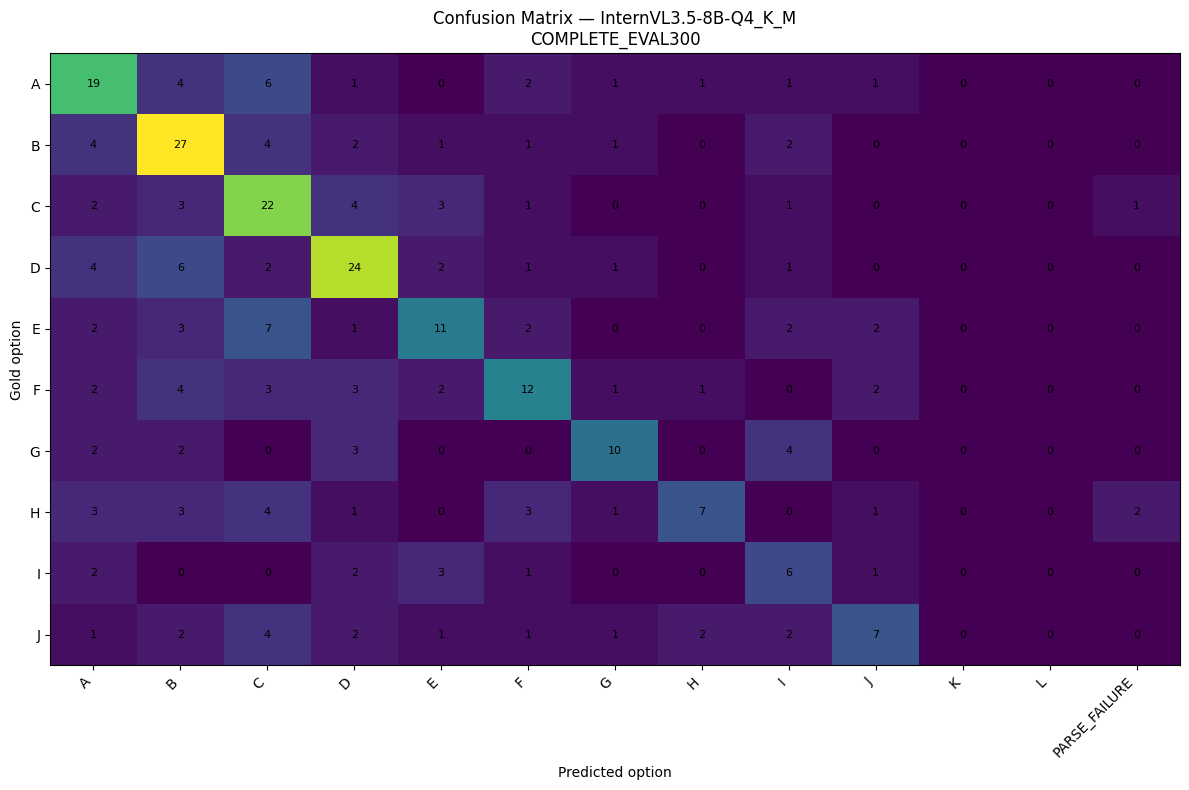

In [23]:
if n_valid:
    max_choices_observed = int(results['n_options'].max())
    observed_choice_labels = choice_letters(max_choices_observed)
    labels = observed_choice_labels + ['PARSE_FAILURE']

    cm = confusion_matrix(yt, yp, labels=labels)

    # Gold labels occupy only rows actually present in the dataset.
    gold_labels_present = [
        label for label in observed_choice_labels
        if label in set(yt)
    ]
    row_indices = [labels.index(label) for label in gold_labels_present]
    cm_display = cm[row_indices, :]

    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(cm_display, aspect='auto')

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_yticks(range(len(gold_labels_present)))
    ax.set_yticklabels(gold_labels_present)

    ax.set_xlabel('Predicted option')
    ax.set_ylabel('Gold option')
    ax.set_title(f'Confusion Matrix — {MODEL}\n{status}')

    for i in range(cm_display.shape[0]):
        for j in range(cm_display.shape[1]):
            ax.text(
                j, i, str(cm_display[i, j]),
                ha='center', va='center', fontsize=8
            )

    fig.tight_layout()
    fig.savefig(
        PLOTS_DIR / 'confusion_matrix.png',
        dpi=180,
        bbox_inches='tight',
    )
    plt.show()


# 19. Runtime, throughput, token cost, output-length and retry metrics

In [24]:
def num(s): return pd.to_numeric(s,errors='coerce')
sessions=read_jsonl(SESSIONS); events=read_jsonl(EVENTS); active_s=sum(float(x.get('session_active_duration_s') or 0) for x in sessions); eff={}
if n_valid:
    successful_latency=num(results['latency_s']).dropna(); sample_wall=num(results['sample_total_wall_s']).dropna(); pt=num(results['prompt_tokens']).dropna(); ct=num(results['completion_tokens']).dropna(); rt=num(results['reasoning_tokens']).dropna(); tt=num(results['total_tokens']).dropna()
    total_pt=float(pt.sum()) if len(pt) else np.nan; total_ct=float(ct.sum()) if len(ct) else np.nan; total_rt=float(rt.sum()) if len(rt) else np.nan; total_tt=float(tt.sum()) if len(tt) else np.nan
    attempt_elapsed=[float(e['elapsed_s']) for e in events if e.get('elapsed_s') is not None and e.get('event')!='retry_backoff']; backoffs=[float(e['backoff_s']) for e in events if e.get('event')=='retry_backoff' and e.get('backoff_s') is not None]; total_success=float(successful_latency.sum())
    eff={'total_active_kaggle_session_s':active_s,'total_active_kaggle_session_h':active_s/3600,'calls_per_min_active_session':60*n_valid/active_s if active_s else np.nan,
      'total_successful_api_latency_s':total_success,'mean_successful_api_latency_s':float(successful_latency.mean()),'median_successful_api_latency_s':float(successful_latency.median()),'p95_successful_api_latency_s':float(successful_latency.quantile(.95)),
      'total_sample_wall_s':float(sample_wall.sum()),'mean_sample_wall_s':float(sample_wall.mean()),'median_sample_wall_s':float(sample_wall.median()),'p95_sample_wall_s':float(sample_wall.quantile(.95)),
      'total_logged_api_attempt_elapsed_s':float(sum(attempt_elapsed)),'total_logged_retry_backoff_s':float(sum(backoffs)),'logged_retry_backoff_events':len(backoffs),
      'total_prompt_tokens':total_pt,'mean_prompt_tokens':float(pt.mean()) if len(pt) else np.nan,'total_completion_tokens':total_ct,'mean_completion_tokens':float(ct.mean()) if len(ct) else np.nan,
      'total_provider_reasoning_tokens_if_exposed':total_rt,'mean_provider_reasoning_tokens_if_exposed':float(rt.mean()) if len(rt) else np.nan,'total_tokens':total_tt,'mean_total_tokens':float(tt.mean()) if len(tt) else np.nan,
      'completion_tokens_per_successful_api_second':total_ct/total_success if total_success>0 and not math.isnan(total_ct) else np.nan,'total_visible_output_chars':int(results['visible_output_chars'].sum()),'mean_visible_output_chars':float(results['visible_output_chars'].mean()),
      'total_visible_output_words':int(results['visible_output_words'].sum()),'mean_visible_output_words':float(results['visible_output_words'].mean()),'total_provider_reasoning_chars_if_exposed':int(results['reasoning_chars'].sum()),
      'mean_provider_reasoning_chars_if_exposed':float(results['reasoning_chars'].mean()),'total_combined_output_chars':int(results['combined_output_chars'].sum()),'mean_combined_output_chars':float(results['combined_output_chars'].mean()),
      'responses_with_more_than_one_attempt_in_successful_pass':int((results['attempts']>1).sum()),'logged_retry_events':sum(1 for e in events if e.get('will_retry') is True and e.get('event')!='retry_backoff'),
      'logged_pass_exhaustions':sum(1 for e in events if e.get('event')=='pass_exhausted_without_valid_response'),'logged_http_429_events':sum(1 for e in events if e.get('http_status')==429),
      'primary_answer_parse_failures':int((~results['answer_parse_success'].astype(bool)).sum()),'exact_format_failures':int((~results['exact_format_compliant'].astype(bool)).sum()),'primary_diagnostic_disagreements':int(results['primary_diagnostic_disagreement'].astype(bool).sum()),'truncated_responses':int(results['truncated'].astype(bool).sum())}
    if PRICE_INPUT_PER_1M_USD is not None and PRICE_OUTPUT_PER_1M_USD is not None: eff['estimated_monetary_api_cost_usd']=total_pt/1e6*PRICE_INPUT_PER_1M_USD+total_ct/1e6*PRICE_OUTPUT_PER_1M_USD
    else: eff['estimated_monetary_api_cost_usd']=None
    display(pd.DataFrame([eff]).T.rename(columns={0:'value'}).round(4))


,value
total_active_kaggle_session_s,4781.905516
total_active_kaggle_session_h,1.328307
calls_per_min_active_session,3.76419
total_successful_api_latency_s,4585.934109
mean_successful_api_latency_s,15.286447
median_successful_api_latency_s,11.991486
p95_successful_api_latency_s,26.385352
total_sample_wall_s,4586.371414
mean_sample_wall_s,15.287905
median_sample_wall_s,11.992959


# 20. Latency and completion-token distributions

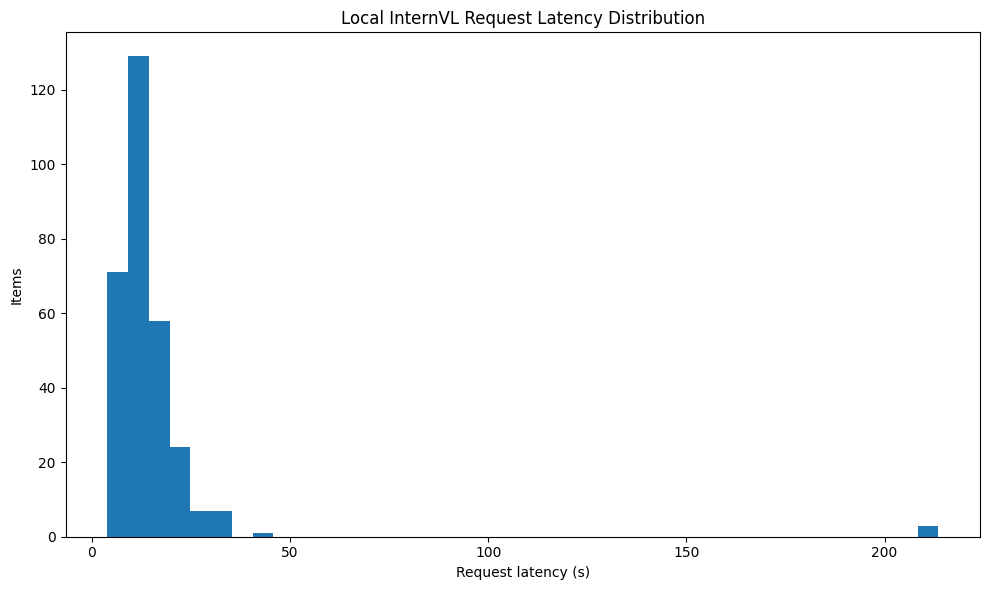

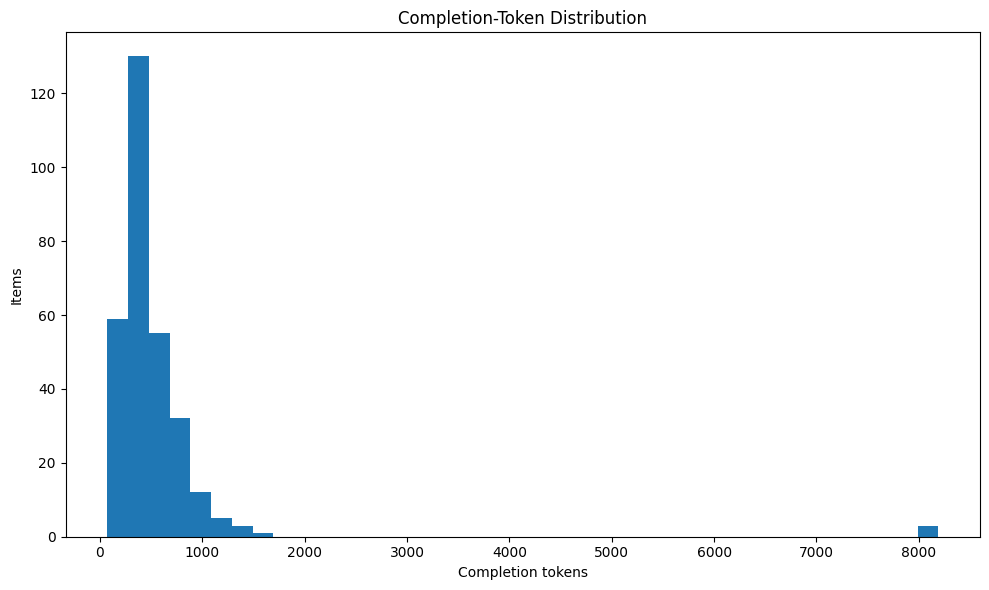

In [25]:
if n_valid:
    fig,ax=plt.subplots(figsize=(10,6)); ax.hist(num(results['latency_s']).dropna(),bins=40); ax.set_xlabel('Request latency (s)'); ax.set_ylabel('Items'); ax.set_title('Local InternVL Request Latency Distribution'); fig.tight_layout(); fig.savefig(PLOTS_DIR/'latency_distribution.png',dpi=180,bbox_inches='tight'); plt.show()
if n_valid and results['completion_tokens'].notna().any():
    fig,ax=plt.subplots(figsize=(10,6)); ax.hist(num(results['completion_tokens']).dropna(),bins=40); ax.set_xlabel('Completion tokens'); ax.set_ylabel('Items'); ax.set_title('Completion-Token Distribution'); fig.tight_layout(); fig.savefig(PLOTS_DIR/'completion_tokens.png',dpi=180,bbox_inches='tight'); plt.show()


# 21. Subject, domain, difficulty, image-type and image-count analyses

In [26]:
DOMAIN={'Art and Design':['Art','Art_Theory','Design','Music'],'Business':['Accounting','Economics','Finance','Manage','Marketing'],
 'Science':['Biology','Chemistry','Geography','Math','Physics'],'Health and Medicine':['Basic_Medical_Science','Clinical_Medicine','Diagnostics_and_Laboratory_Medicine','Pharmacy','Public_Health'],
 'Humanities and Social Science':['History','Literature','Sociology','Psychology'],'Tech and Engineering':['Agriculture','Architecture_and_Engineering','Computer_Science','Electronics','Energy_and_Power','Materials','Mechanical_Engineering']}
S2D={s:d for d,ss in DOMAIN.items() for s in ss}
def group_acc(df,col): return df.groupby(col,dropna=False).agg(n=('sample_id','size'),correct=('answer_correct','sum'),accuracy=('answer_correct','mean'),mean_latency_s=('latency_s','mean'),mean_completion_tokens=('completion_tokens','mean')).reset_index()
if n_valid:
    results['domain']=results['subject'].map(S2D).fillna('Other/Unmapped')
    subject=group_acc(results,'subject'); domain=group_acc(results,'domain'); diff=group_acc(results,'topic_difficulty'); imgt=group_acc(results,'img_type'); imgc=group_acc(results,'image_count')
    subject.to_csv(SUBJECT_CSV,index=False); domain.to_csv(DOMAIN_CSV,index=False); diff.to_csv(DIFF_CSV,index=False); imgt.to_csv(IMGTYPE_CSV,index=False); imgc.to_csv(IMGCOUNT_CSV,index=False)
    print('Domain'); display(domain.round(4)); print('Difficulty'); display(diff.round(4)); print('Image count'); display(imgc.round(4)); print('Subject'); display(subject.round(4))


Domain


,domain,n,correct,accuracy,mean_latency_s,mean_completion_tokens
0,Art and Design,40,20,0.5000,9.8241,291.6250
1,Business,50,27,0.5400,14.0597,512.5800
2,Health and Medicine,50,27,0.5400,10.7480,377.0600
3,Humanities and Social Science,40,23,0.5750,11.7294,371.3000
4,Science,50,22,0.4400,20.1168,732.5600
5,Tech and Engineering,70,26,0.3714,21.1082,786.9143


Difficulty


,topic_difficulty,n,correct,accuracy,mean_latency_s,mean_completion_tokens
0,Easy,88,53,0.6023,12.7691,439.8636
1,Hard,88,29,0.3295,15.9736,566.0341
2,Medium,124,63,0.5081,16.5853,598.3226


Image count


,image_count,n,correct,accuracy,mean_latency_s,mean_completion_tokens
0,1,278,134,0.4820,15.4874,557.7806
1,2,12,10,0.8333,13.2093,360.1667
2,3,1,0,0.0000,7.1591,246.0000
3,4,5,0,0.0000,10.1731,296.6000
4,5,4,1,0.2500,15.9724,399.2500


Subject


,subject,n,correct,accuracy,mean_latency_s,mean_completion_tokens
0,Accounting,10,8,0.8,13.6704,511.9
1,Agriculture,10,4,0.4,11.8005,351.6
2,Architecture_and_Engineering,10,6,0.6,21.5825,841.1
3,Art,10,5,0.5,10.3368,304.4
4,Art_Theory,10,7,0.7,10.2272,278.0
5,Basic_Medical_Science,10,3,0.3,9.8283,344.9
6,Biology,10,2,0.2,12.8135,417.3
7,Chemistry,10,6,0.6,9.9000,349.4
8,Clinical_Medicine,10,8,0.8,11.6834,424.7
9,Computer_Science,10,3,0.3,16.0634,521.2


# 22. Answer-position bias diagnostics

,letter,gold_count,predicted_count
0,A,36,41
1,B,42,54
2,C,37,52
3,D,41,43
4,E,30,23
5,F,30,24
6,G,21,16
7,H,25,11
8,I,15,19
9,J,23,14


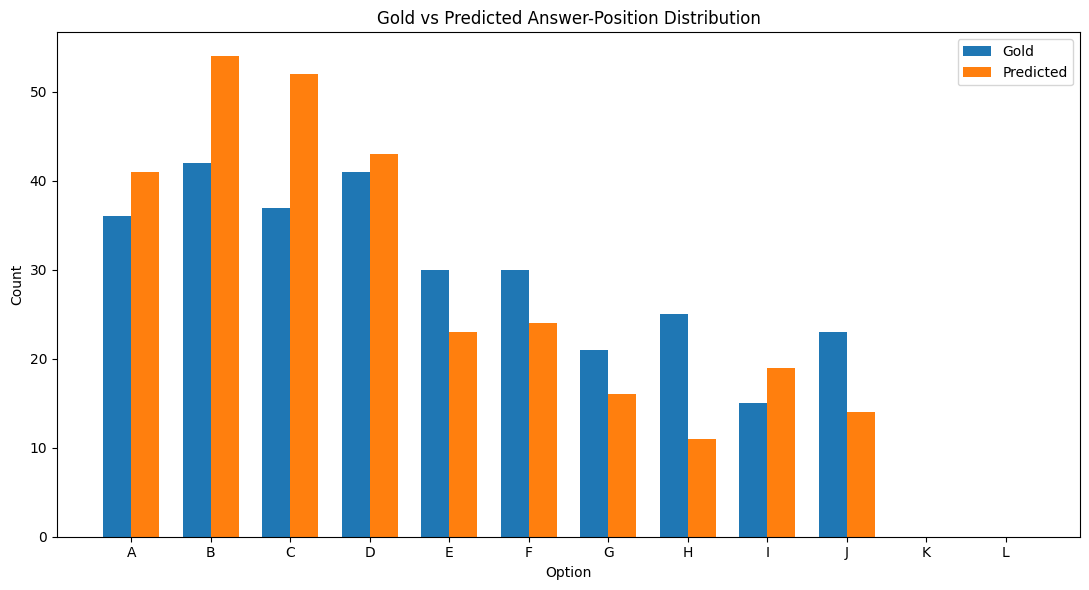

In [27]:
if n_valid:
    position_labels = choice_letters(int(results['n_options'].max()))

    g = results['gold_answer'].value_counts().reindex(position_labels, fill_value=0)
    p = results['answer_prediction'].value_counts().reindex(position_labels, fill_value=0)

    pos = pd.DataFrame({
        'letter': position_labels,
        'gold_count': g.values,
        'predicted_count': p.values,
    })
    display(pos)

    x = np.arange(len(position_labels))
    w = .35
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.bar(x - w/2, pos['gold_count'], w, label='Gold')
    ax.bar(x + w/2, pos['predicted_count'], w, label='Predicted')
    ax.set_xticks(x)
    ax.set_xticklabels(position_labels)
    ax.set_xlabel('Option')
    ax.set_ylabel('Count')
    ax.set_title('Gold vs Predicted Answer-Position Distribution')
    ax.legend()
    fig.tight_layout()
    fig.savefig(PLOTS_DIR/'answer_positions.png', dpi=180, bbox_inches='tight')
    plt.show()


# 23. Consolidated paper-ready summary

In [28]:
summary = {
    'analysis_status': status,
    'complete': complete,
    'experiment_id': EXPERIMENT_ID,
    'experiment_signature': EXPERIMENT_SIGNATURE,
    'protocol_version': PROTOCOL_VERSION,
    'parser_version': PARSER_VERSION,
    'parser_spec_sha256': PARSER_SPEC_SHA256,
    'scoring_signature': SCORING_SIGNATURE,
    'evaluation_cohort_id': EVALUATION_COHORT_ID,
    'model': MODEL,
    'provider': PROVIDER,
    'api_method': API_METHOD,
    'dataset_revision': DATASET_REVISION,
    'n_dataset': n_total,
    'n_valid': n_valid,
    'n_missing': n_total - n_valid,
    'coverage': coverage,
    'prompt_id': PROMPT_ID,
    'prompt_family': PROMPT_FAMILY,
    'prompt_suffix_sha256': PROMPT_SUFFIX_SHA,
    'prompt_template_sha256': PROMPT_TEMPLATE_SHA,
    'question_prefix_added': False,
    'selection_protocol': SELECTION_PROTOCOL_NAME,
    'selected_ids_sha256': SELECTED_IDS_CANONICAL_SHA256,
    'source_rows': len(source_ds),
    'classification': classification,
    'efficiency': eff,
    'primary_answer_parse_rate': None if pd.isna(parse_rate) else float(parse_rate),
    'exact_format_compliance_rate': None if pd.isna(fmt) else float(fmt),
    'primary_diagnostic_disagreement_rate': (
        None if pd.isna(diagnostic_disagreement_rate)
        else float(diagnostic_disagreement_rate)
    ),
    'truncation_rate': None if pd.isna(trunc) else float(trunc),
}
SUMMARY_JSON.write_text(
    json.dumps(summary, ensure_ascii=False, indent=2), encoding='utf-8'
)
flat_summary = {
    'analysis_status': status,
    'complete': complete,
    'experiment_signature': EXPERIMENT_SIGNATURE,
    'protocol_version': PROTOCOL_VERSION,
    'parser_version': PARSER_VERSION,
    'parser_spec_sha256': PARSER_SPEC_SHA256,
    'scoring_signature': SCORING_SIGNATURE,
    'model': MODEL,
    'provider': PROVIDER,
    'api_method': API_METHOD,
    'dataset_revision': DATASET_REVISION,
    'n_dataset': n_total,
    'n_valid': n_valid,
    'n_missing': n_total - n_valid,
    'coverage': coverage,
    **classification,
    **eff,
}
pd.DataFrame([flat_summary]).to_csv(SUMMARY_CSV, index=False)
display(pd.DataFrame([flat_summary]).T.rename(columns={0: 'value'}))


,value
analysis_status,COMPLETE_EVAL300
complete,True
experiment_signature,3fefd36d9c66b2079b555b6da832dc8df9d7837bddaa67...
protocol_version,P1_COT_INTERNVL35_8B_Q4KM_LOCAL_EVAL300_IMAGEO...
parser_version,deterministic_final_line_answer_v1
...,...
primary_answer_parse_failures,3
exact_format_failures,3
primary_diagnostic_disagreements,0
truncated_responses,3


# 24. Professional qualitative audit viewer

In [29]:
def br(x): return html.escape(str(x or '')).replace('\n','<br>')
if GENERATE_HTML_AUDIT and n_valid:
    cards=[]
    for _,r in results.sort_values('execution_order').iterrows():
        imgs=''.join(f'<img src="{html.escape(p)}" style="max-width:420px;max-height:320px;margin:6px;border:1px solid #ddd">' for p in str(r['image_files']).split(';') if p)
        opts=json.loads(r['options_json']); ol='<ol type="A">'+''.join(f'<li>{html.escape(str(o))}</li>' for o in opts)+'</ol>'
        verdict='CORRECT' if bool(r['answer_correct']) else 'WRONG'
        cards.append(f"""<section style="border:1px solid #bbb;padding:16px;margin:18px 0"><h2>{html.escape(str(r['sample_id']))} — {verdict}</h2>
        <p><b>Subject:</b> {html.escape(str(r['subject']))}<br><b>Primary answer prediction:</b> {html.escape(str(r['answer_prediction']))}<br><b>Primary parse method:</b> {html.escape(str(r['answer_parse_method']))}<br><b>Exact requested format:</b> {html.escape(str(bool(r['exact_format_compliant'])))}<br><b>Gold:</b> {html.escape(str(r['gold_answer']))} — {html.escape(str(r['gold_option_text']))}</p>
        <div>{imgs}</div><h3>Question</h3><p>{br(r['question'])}</p><h3>Options</h3>{ol}<h3>Visible model response</h3><div style="background:#f6f6f6;padding:10px">{br(r['visible_response'])}</div>
        <h3>Model-provided reasoning field</h3><div style="background:#fafafa;padding:10px">{br(r['reasoning_content'])}</div><h3>Gold explanation — intentionally excluded from inference records</h3><div style="background:#fff9e8;padding:10px">{br(r['gold_explanation'])}</div></section>""")
    doc=f'<!doctype html><html><head><meta charset="utf-8"><title>{EXPERIMENT_ID}</title></head><body style="font-family:Arial;max-width:1200px;margin:auto;padding:20px"><h1>{EXPERIMENT_ID}</h1><p><b>Status:</b> {status}; {n_valid}/{n_total}</p>'+''.join(cards)+'</body></html>'
    AUDIT_HTML.write_text(doc,encoding='utf-8'); print('Saved',AUDIT_HTML)


Saved /kaggle/working/internvl35_8b_p1_cot_eval300_MAX8192_CTX16384_localinput_v1/audit_viewer.html


# 25. README_RESULTS.md and final completion gate

In [30]:
def pct(x):
    return "N/A" if x is None or pd.isna(x) else f"{100*float(x):.2f}%"

readme = f"""# {EXPERIMENT_ID}

## Status
**{status}** — {n_valid}/{n_total} valid model responses.

## Dataset
- Source: `{DATASET_REPO}` / `{DATASET_CONFIG}` / `{DATASET_SPLIT}`
- Revision: `{DATASET_REVISION}`
- Full source rows: `{len(source_ds)}`
- Selected IDs SHA256: `{SELECTED_IDS_CANONICAL_SHA256}`
- Selected rows: `{len(ds)}`
- Subjects: `{len(selected_subject_counts)}` (10 each)
- Execution order SHA256: `{ORDER_SHA}`

## Local InternVL model — P1 CoT
- Model: `{MODEL}`
- Base model: `{BASE_MODEL}`
- Quantization: `{QUANTIZATION}`
- Preferred prior address: `{PREFERRED_MODEL_PATH}`
- Resolved model path: `{MODEL_PATH}`
- Model SHA256: `{MODEL_SHA_OBSERVED}`
- Projector: `{MMPROJ_FILENAME}` / SHA256 `{MMPROJ_SHA_OBSERVED}`
- Runtime: `{version_text.strip()}`
- Runtime SHA256: `{LLAMA_SHA_OBSERVED}`
- GPUs: `{gpu_names}`
- Context size: `{CTX_SIZE}`
- Tensor split: `{TENSOR_SPLIT}`

## Generation
- Temperature: `{TEMPERATURE}`
- Top-p sent: `False`
- Top-k sent: `False`
- Max output tokens: `{MAX_TOKENS}`
- Seed: `{API_SEED}`
- Stream: `{STREAM}`
- Thinking mode: default InternVL non-thinking mode; no thinking system prompt is supplied. `--reasoning off` disables llama reasoning parsing only.

## Input construction
- images first in numbered-marker occurrence order
- repeated image references repeat the image block
- numbered `<image n>` markers normalized to `<image>`
- lossless PNG base64 data URIs
- text block last; no system message
- no `Question:` prefix, demonstrations, gold answer or source explanation

## Scheduling and resume
- main timeout: `{REQUEST_TIMEOUT_S}` s
- deferred timeout: `{DEFERRED_REQUEST_TIMEOUT_S}` s
- main attempts: `{MAX_ATTEMPTS}`
- deferred attempts: `{DEFERRED_MAX_ATTEMPTS}`
- deferred retry passes: `{DEFERRED_RETRY_PASSES}`
- timed-out local generations restart the server before later work
- exact-signature checkpoints are validated record-by-record
- only IDs without a valid model response are sent again
- valid parse failures and truncated generations are retained, not regenerated

## P1 CoT prompt suffix
```text
{PROMPT_SUFFIX}
```

Prompt suffix SHA256: `{PROMPT_SUFFIX_SHA}`
Prompt template SHA256: `{PROMPT_TEMPLATE_SHA}`

## Frozen scoring
- Parser version: `{PARSER_VERSION}`
- Parser specification SHA256: `{PARSER_SPEC_SHA256}`
- Scoring signature: `{SCORING_SIGNATURE}`
- Primary: deterministic, gold-blind last-non-empty-line answer accuracy
- Accepted wrappers: `Answer: B`, `Answer: $B`, `Answer: $B$`, `Answer: (B)`; optional final period
- `$LETTER` is a placeholder; exact instantiated compliance is `Answer: B`
- no random fallback and no primary scan of the reasoning body
- truncated responses are unparsed and incorrect
- every checkpointed raw response is reparsed under this frozen parser

## Headline results
- Primary answer accuracy: {pct(classification.get('primary_answer_accuracy'))}
- Macro F1: {classification.get('macro_f1','N/A')}
- Weighted F1: {classification.get('weighted_f1','N/A')}
- Primary answer parse rate: {pct(parse_rate)}
- Exact requested-format compliance: {pct(fmt)}
- Diagnostic MMMU-Pro-style accuracy: {pct(classification.get('diagnostic_mmmupro_style_accuracy_no_random_fallback'))}
- Primary/diagnostic disagreement: {pct(diagnostic_disagreement_rate)}
- Incomplete/truncation rate: {pct(trunc)}

## Error-analysis export
- `{ERROR_ANALYSIS_CSV.name}`: all primary answer errors
- `{PARSER_AUDIT_CSV.name}`: formatting/parser/truncation audit
- formatting-only deviations are not mislabeled as content errors

Final headline metrics are reportable only when status is `COMPLETE_EVAL300` and
all 300 selected IDs have one validated model response.
"""
README.write_text(readme, encoding="utf-8")
print(readme)


# MMMUPro-Eval300__InternVL3.5-8B-Q4_K_M__P1-CoT-StepByStep__LocalLlamaCpp__ImageOrderFix__ValidatedResume__LongDeferredTimeout__Temperature0__Seed42__MAX8192__CTX16384__LocalInput

## Status
**COMPLETE_EVAL300** — 300/300 valid model responses.

## Dataset
- Source: `MMMU/MMMU_Pro` / `standard (10 options)` / `test`
- Revision: `563f3e84bb3b90893083a1f039cfa13077f2302b`
- Full source rows: `1730`
- Selected IDs SHA256: `db7ec6dca5dff71d8ea8551a08c448c4314e153509ce9c78d2e8c652011a5dc3`
- Selected rows: `300`
- Subjects: `30` (10 each)
- Execution order SHA256: `789bc1ac18805986f38c3aea51adaa5f33ac533e3398247170a4e4501e2605d3`

## Local InternVL model — P1 CoT
- Model: `InternVL3.5-8B-Q4_K_M`
- Base model: `OpenGVLab/InternVL3_5-8B`
- Quantization: `Q4_K_M`
- Preferred prior address: `/kaggle/input/notebooks/vernvern/notebookf785af4a9b/internvl35_8b_saved/InternVL3_5-8B-Q4_K_M.gguf`
- Resolved model path: `/kaggle/input/notebooks/vernvern/notebookf785af4a9b/internvl35_8b_saved/InternVL3

# 27. Suggested Methods wording for the P1 CoT Eval300 experiment

methods = f"""
We evaluated {MODEL} ({QUANTIZATION}) under the P1 zero-shot chain-of-thought
condition on the frozen balanced 300-item MMMU-Pro cohort. All dataset, image
ordering, decoding, parser, scoring, checkpoint, and resume settings were held
fixed relative to the baseline.

P1 changed only the textual instruction: after the final-answer format
requirement, the prompt added `Think step by step before answering.` and retained
`Explain your reasoning before answering.`. The P1 suffix SHA-256 was
{PROMPT_SUFFIX_SHA}.

The locally attached InternVL3.5-8B Q4_K_M model, F16 projector, and llama
runtime were SHA-256 verified. Inference used two T4 GPUs, context {CTX_SIZE},
temperature {TEMPERATURE}, no explicit top-p/top-k, output cap {MAX_TOKENS}, and
seed {API_SEED}. No model-specific thinking request parameter was sent; llama
reasoning parsing was disabled with `--reasoning off`.
""".strip()

print(methods)
(WORKDIR / "METHODS_SUGGESTION.txt").write_text(methods + "\n", encoding="utf-8")
